In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Library primitives only — general loaders, filters, plotters, styling.
# Section-specific configs (group keys, color maps, suptitles) live in the
# cells that use them. Every standard_sweep_figure call gets the AdamW
# baseline + uniform layout for free.
from lora_playground.plot_utils import (
    DIVERGE_THRESHOLD, OPTIM_COLORS, OPTIM_MARKERS,
    has_runs, max_loss, parse_flag,
    best_run,
    plot_leaderboard_by_rank, standard_sweep_figure,
)
from lora_playground.loader import load_runs, inventory_runs, render_inventory

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [3]:
# Single source of truth for "what could be silently wrong" — orphans,
# self-deprecated groups, optimizers in logs but missing from OPTIM_COLORS,
# and (optimizer, rank, mult) cells whose best lr is at the swept boundary.
print(render_inventory(inventory_runs("../logs")))

Loaded 59 of 60 groups on disk.

UNKNOWN OPTIMIZERS (3) — in logs but missing from OPTIM_COLORS, will be dropped by any cell that filters on it:
  kfac-lora
  svd-cumulative-adamw
  svd-step-adamw

Coverage: 60 (optimizer, rank, mult) cells
PINNED at lr-range boundary (15) — extension sweep recommended:
  adam-lin-lora                     r=2           best_lr=1e-03 (final=0.7914)   swept=['3e-04', '1e-03'] → pinned_high
  adam-lin-lora                     r=4           best_lr=1e-03 (final=0.7782)   swept=['3e-04', '1e-03'] → pinned_high
  adam-lin-lora-matrix              r=64          best_lr=1e-03 (final=0.7690)   swept=['3e-04', '1e-03'] → pinned_high
  adam-product-muon-lora            r=16   m=4    best_lr=3e-04 (final=0.8271)   swept=['3e-04', '1e-03', '3e-03', '1e-02'] → pinned_low
  adam-scaled-lora                  r=2           best_lr=1e-03 (final=0.7909)   swept=['3e-04', '1e-03'] → pinned_high
  adam-scaled-lora                  r=4           best_lr=1e-03 (final=0.7777)

In [4]:
# Section-specific palettes (general OPTIM_COLORS imported from library).
M_COLORS = {1: plt.cm.plasma(0.15), 4: plt.cm.plasma(0.50), 16: plt.cm.plasma(0.85)}
MODE_COLORS = {"svd_step_oracle": "#ff7f0e", "svd_cumulative_oracle": "#2ca02c"}

# Convention: same color per base optimizer across all m. m differentiation
# happens via MUON_VARIANT_MARKERS, not color. This keeps families visually
# consistent across the leaderboard and the muon-variants panel.
MUON_VARIANT_COLORS = {
    "muon":              OPTIM_COLORS["muon-lora"],
    "muon+m=4":          OPTIM_COLORS["muon-lora"],
    "muon+m=16":         OPTIM_COLORS["muon-lora"],
    "muon+ns=0":         "#bababa",  # ns=0 is a sanity-check variant, distinct
    "product-muon":      OPTIM_COLORS["product-muon-lora"],
    "product-muon+m=4":  OPTIM_COLORS["product-muon-lora"],
    "adam-muon":         OPTIM_COLORS["adam-muon-lora"],
    "adam-muon+m=4":     OPTIM_COLORS["adam-muon-lora"],
}

MUON_VARIANT_MARKERS = {
    "muon":              "o",
    "muon+m=4":          "D",
    "muon+m=16":         "P",
    "muon+ns=0":         "x",
    "product-muon":      "o",
    "product-muon+m=4":  "D",
    "adam-muon":         "o",   # base marker, matches OPTIM_MARKERS convention
    "adam-muon+m=4":     "D",
}

MUON_VARIANT_LINESTYLES = {
    "muon":              "-",                    # m=1 solid
    "muon+m=4":          (0, (5, 2)),              # m=4 long-dash
    "muon+m=16":         (0, (1, 2)),              # m=16 dotted
    "muon+ns=0":         (0, (3, 2, 1, 2)),        # ns=0 dash-dot
    "product-muon":      "-",
    "product-muon+m=4":  (0, (5, 2)),
    "adam-muon":         "-",
    "adam-muon+m=4":     (0, (5, 2)),
}

## Optimizer comparison by family

Each family panel tests a specific composition class against AdamW. Uninformative low-performers (no-Adam baselines, per-coord K-FAC family, GaLore, unfixed `*-post`) are dropped — they're consistently 0.03+ above AdamW per the synthesis, and clutter the visual without adding signal.

All numbers are single-seed at the canonical 2k-step horizon; multi-seed verification is deferred. Δ values describe the single seed measured, not seed-to-seed significance.

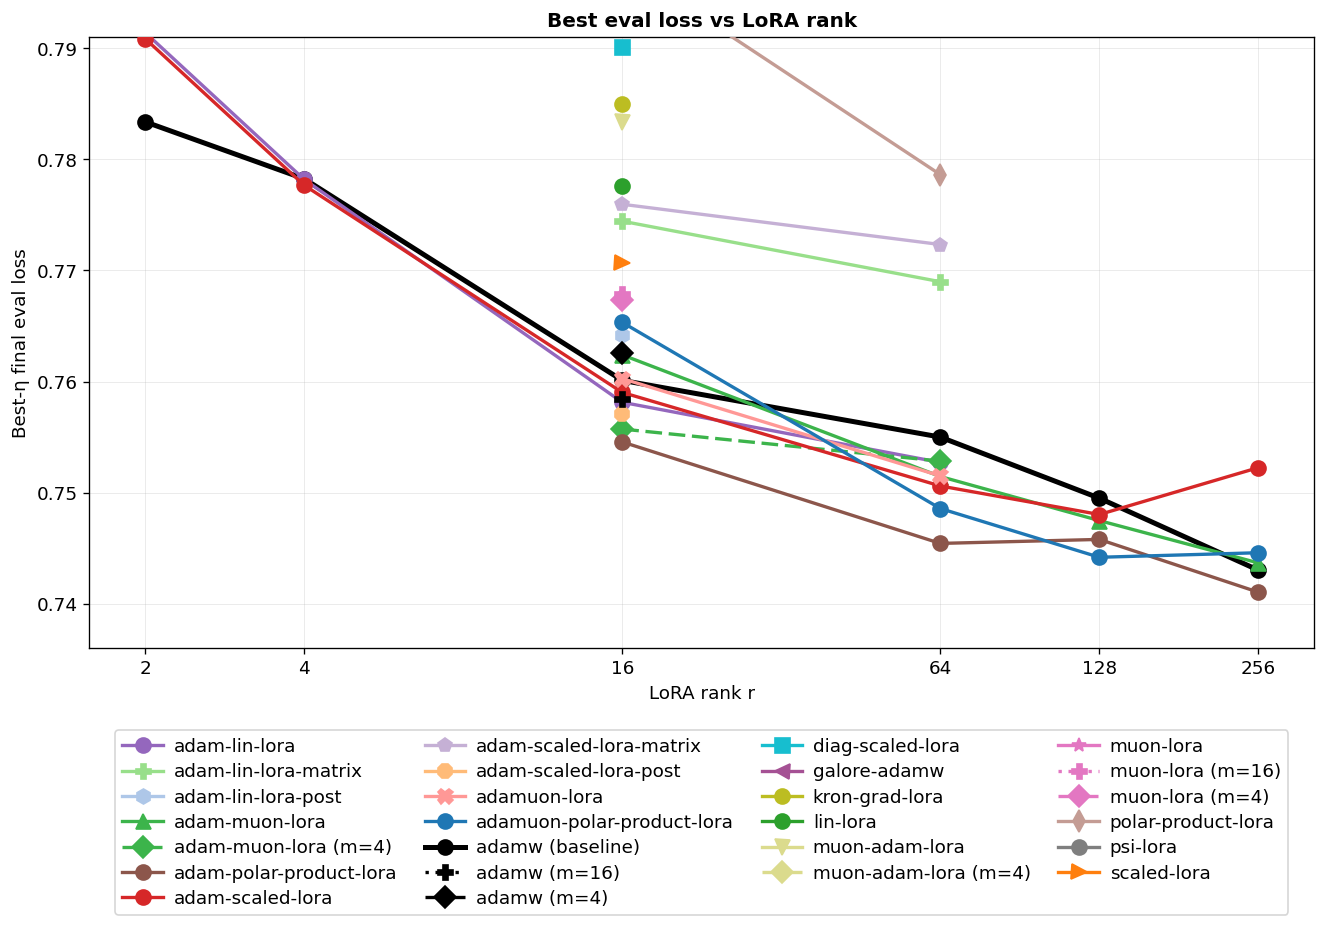

In [5]:
# Optimizer comparison across LoRA ranks: load every run for any optimizer
# in OPTIM_COLORS, plot per-rank best-η + leaderboard.
# Includes m≠1 (LoRA+) variants as distinct entries — m=1 gets the bare optimizer
# label, m≠1 gets a "(m=N)" suffix so the LoRA+ contribution is visible separately.
RENAME_ALIAS = {"psi-lora": "diag-scaled-lora", "kfac-lora": "kron-grad-lora"}
NEW_PSI_GROUPS = {"psi_lora_2k"}

def _alias(c, group):
    c["_lora_r"] = int(c.get("lora_r", 16))
    if group not in NEW_PSI_GROUPS:
        c["optimizer"] = RENAME_ALIAS.get(c["optimizer"], c["optimizer"])
    m = float(c.get("lora_plus_multiplier", 1.0))
    c["_label"] = c["optimizer"] if m == 1.0 else f"{c['optimizer']} (m={int(m)})"

ext_runs = load_runs(
    where={"optimizer": list(OPTIM_COLORS)},
    key_axes=("optimizer", "lr", "lora_r", "lora_plus_multiplier"),
    cfg_postprocess=_alias,
    logs_root="../logs",
)

# Best-η per (label, r) at step 2000 — label includes m so m=1 and m=4 appear separately.
best = {}
for cfg, evs in ext_runs:
    if evs[-1]["step"] < 2000:
        continue
    k = (cfg["_label"], cfg["_lora_r"])
    fl = evs[-1]["eval_loss"]
    if k not in best or fl < best[k][2]:
        best[k] = (cfg, evs, fl)

# Convention: same color per base optimizer across all m. m≠1 variants are
# differentiated by marker only (D/P/X for m∈{4,16,32}), keeping the same
# family color so an optimizer reads consistently across panels.
import re
def _base(label):
    return label.split(" (m=")[0]
_M_MARKERS = {4: "D", 16: "P", 32: "X"}
_color_map = {}
_marker_map = {}
for (lab, _) in best:
    base_opt = _base(lab)
    _color_map[lab] = OPTIM_COLORS.get(base_opt, "grey")
    m_match = re.search(r"\(m=(\d+)\)", lab)
    if m_match:
        _marker_map[lab] = _M_MARKERS.get(int(m_match.group(1)), "*")
    else:
        _marker_map[lab] = OPTIM_MARKERS.get(base_opt, "o")
_color_map["adamw"] = OPTIM_COLORS["adamw"]

# Linestyle per m: m=1 solid, m=4 long-dash, m=16 dotted, m=32 dash-dot.
_M_LINESTYLES = {1: "-", 4: (0, (5, 2)), 16: (0, (1, 2)), 32: (0, (3, 2, 1, 2))}
_linestyle_map = {}
for (lab, _) in best:
    m_match = re.search(r"\(m=(\d+)\)", lab)
    m = int(m_match.group(1)) if m_match else 1
    _linestyle_map[lab] = _M_LINESTYLES.get(m, "-")

plot_leaderboard_by_rank(best, baseline_optimizer="adamw", color_map=_color_map,
                          marker_map=_marker_map, linestyle_map=_linestyle_map,
                          suptitle="Best eval loss vs LoRA rank")
plt.show()

In [6]:
# all_runs: AdamW + comprehensive baseline data at r=16, used downstream as
# the reference overlay for SVD / LoRA+ / muon panels. We do NOT plot all_runs
# as a single 10-curve figure — that's the messy view we removed in the
# family reorg. This cell loads only.
RENAME_ALIAS = {"psi-lora": "diag-scaled-lora", "kfac-lora": "kron-grad-lora"}
NEW_PSI_GROUPS = {"psi_lora_2k"}

def _alias_optimizer(cfg, group):
    if group not in NEW_PSI_GROUPS:
        cfg["optimizer"] = RENAME_ALIAS.get(cfg["optimizer"], cfg["optimizer"])

# r=16 only (the reference overlay's purpose) and m=1 (excludes LoRA+ cells
# that share the same (optimizer, lr) key and would otherwise collide).
all_runs = load_runs(
    where={"optimizer": list(OPTIM_COLORS), "lora_r": 16, "lora_plus_multiplier": 1.0},
    key_axes=("optimizer", "lr"),
    cfg_postprocess=_alias_optimizer,
    logs_root="../logs",
)
print(f"all_runs (r=16 reference overlay): {len(all_runs)} runs across "
      f"{len({c['optimizer'] for c, _ in all_runs})} optimizers")

all_runs (r=16 reference overlay): 127 runs across 22 optimizers


### Pre-Adam (geometry → Adam)

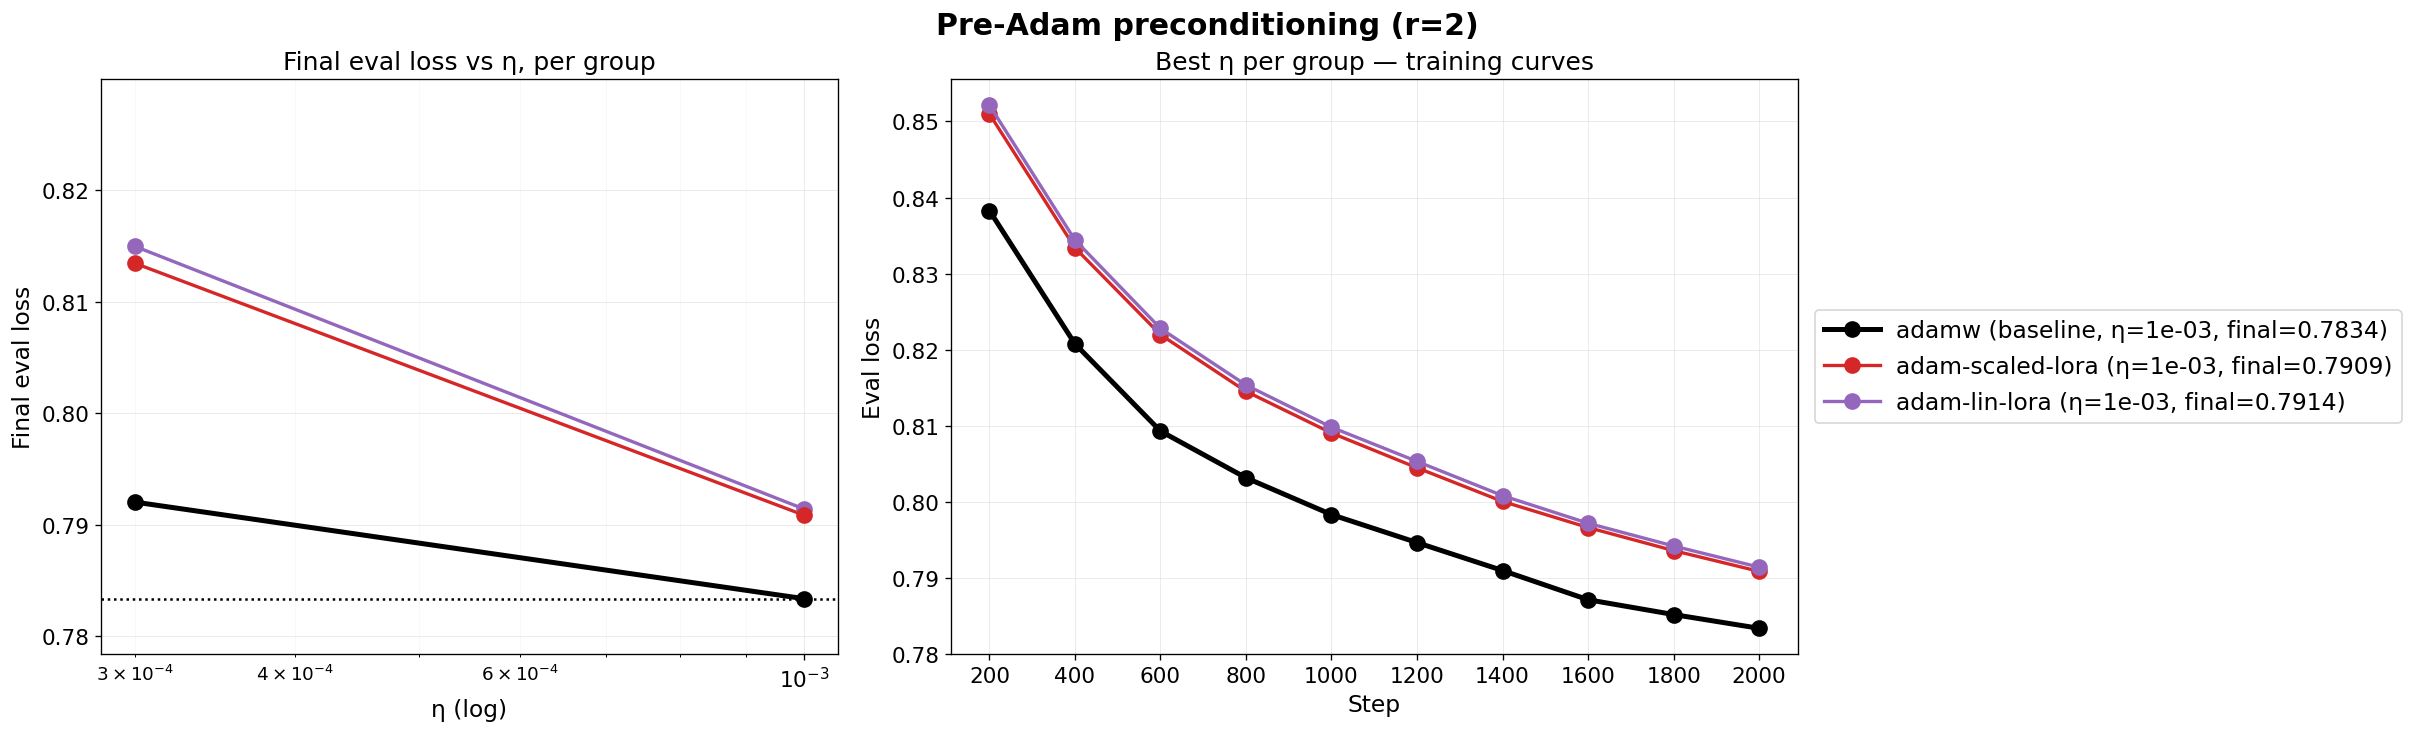

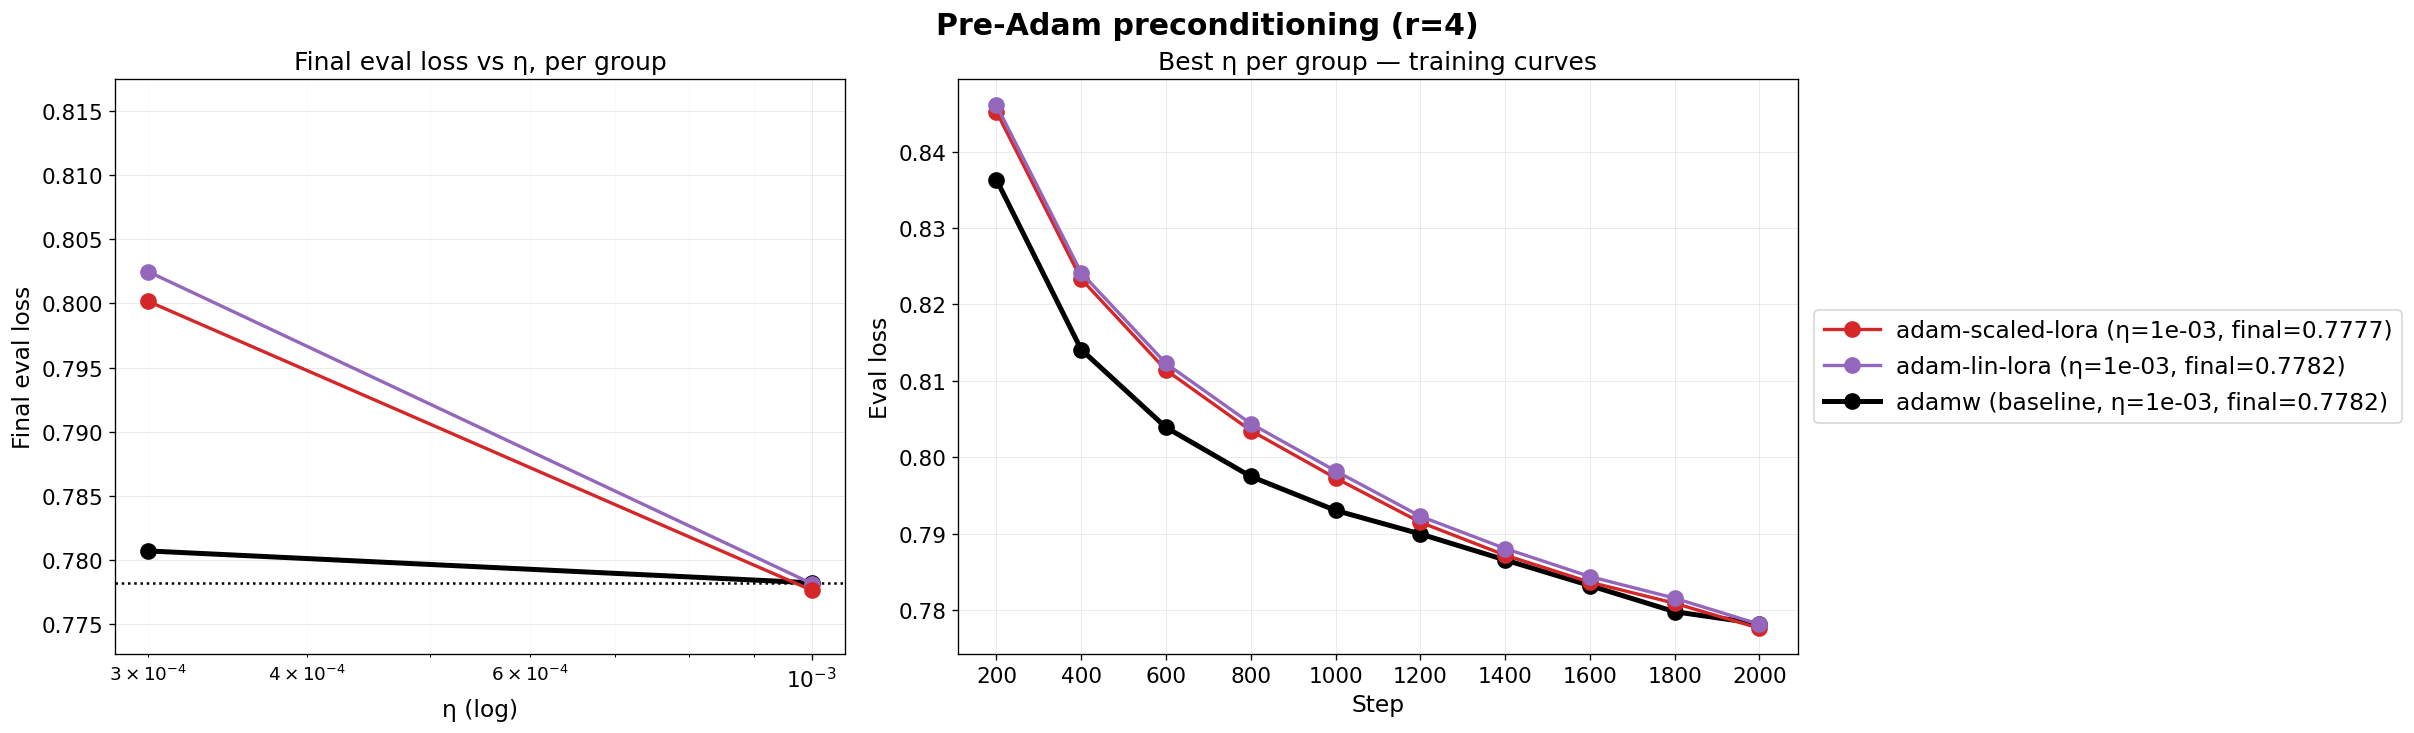

  [filtered diverged] adam-scaled-lora η=1e-02 max=2.269 final=1.665
  [filtered diverged] adamw η=1e-02            max=9.009 final=6.937
  [clipped from left panel y_cap=0.908] 2 run(s):
    adam-lin-lora η=1e-02 final=1.3112
    adamw η=3e-03 final=1.0223


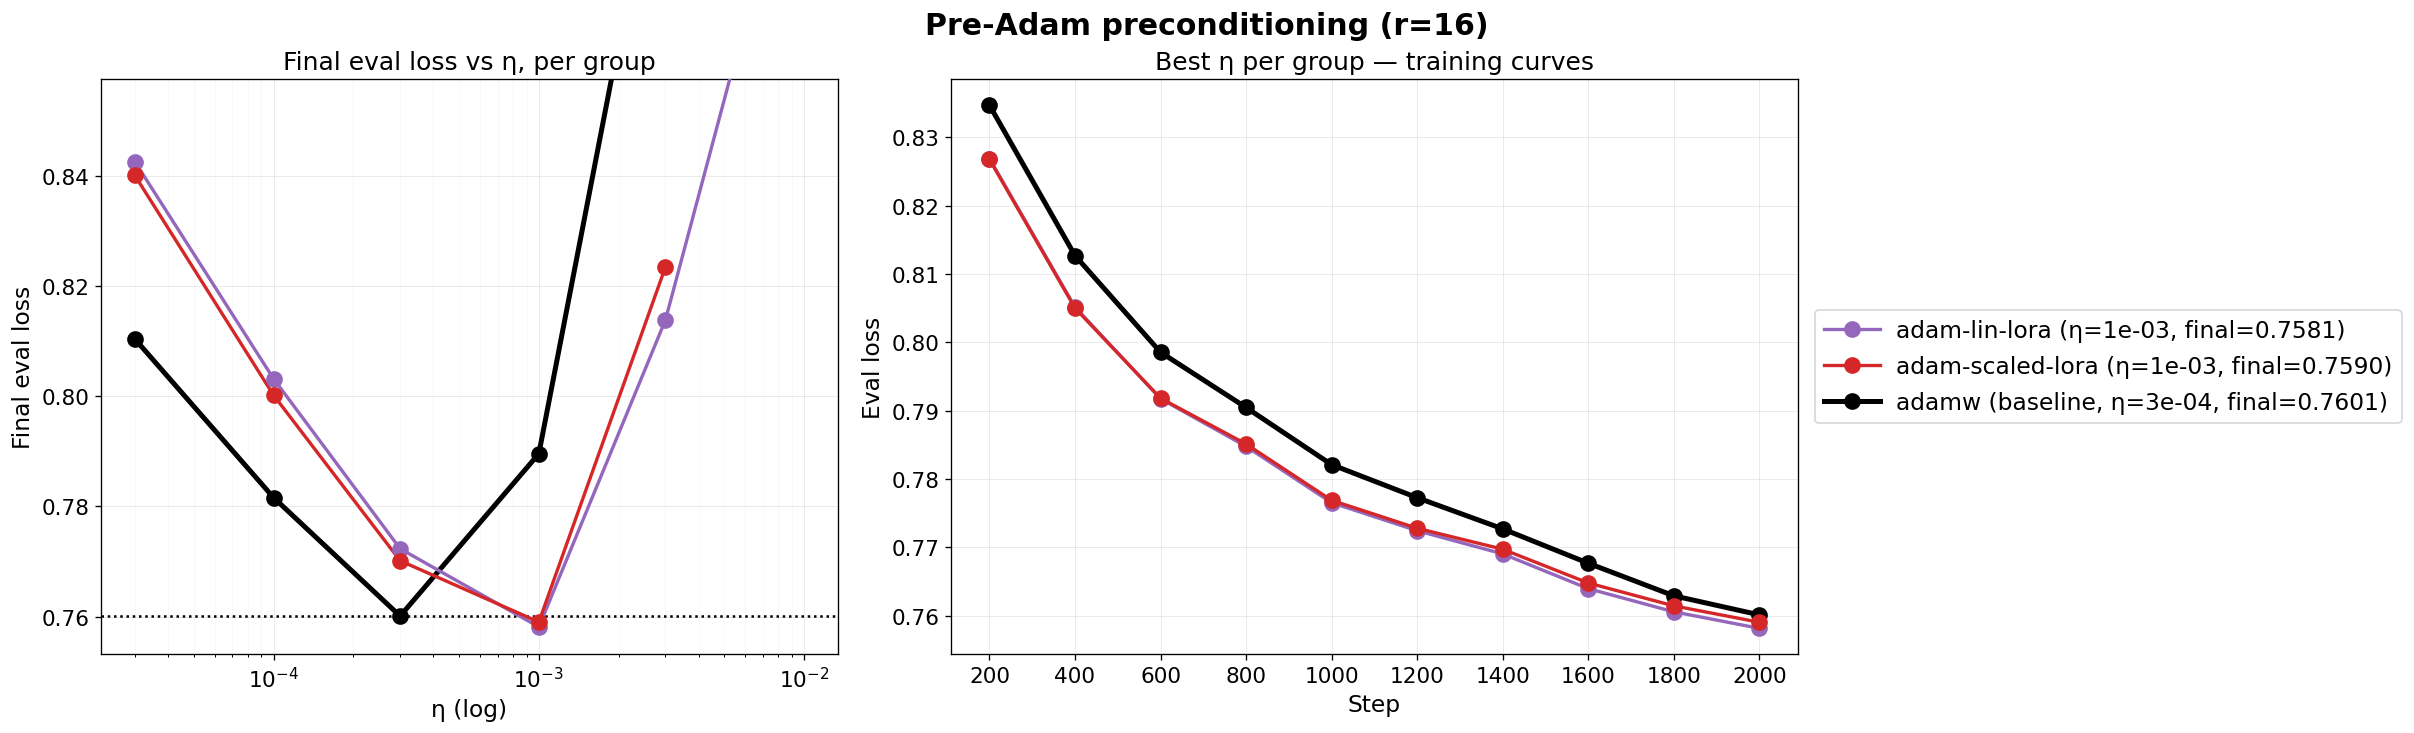

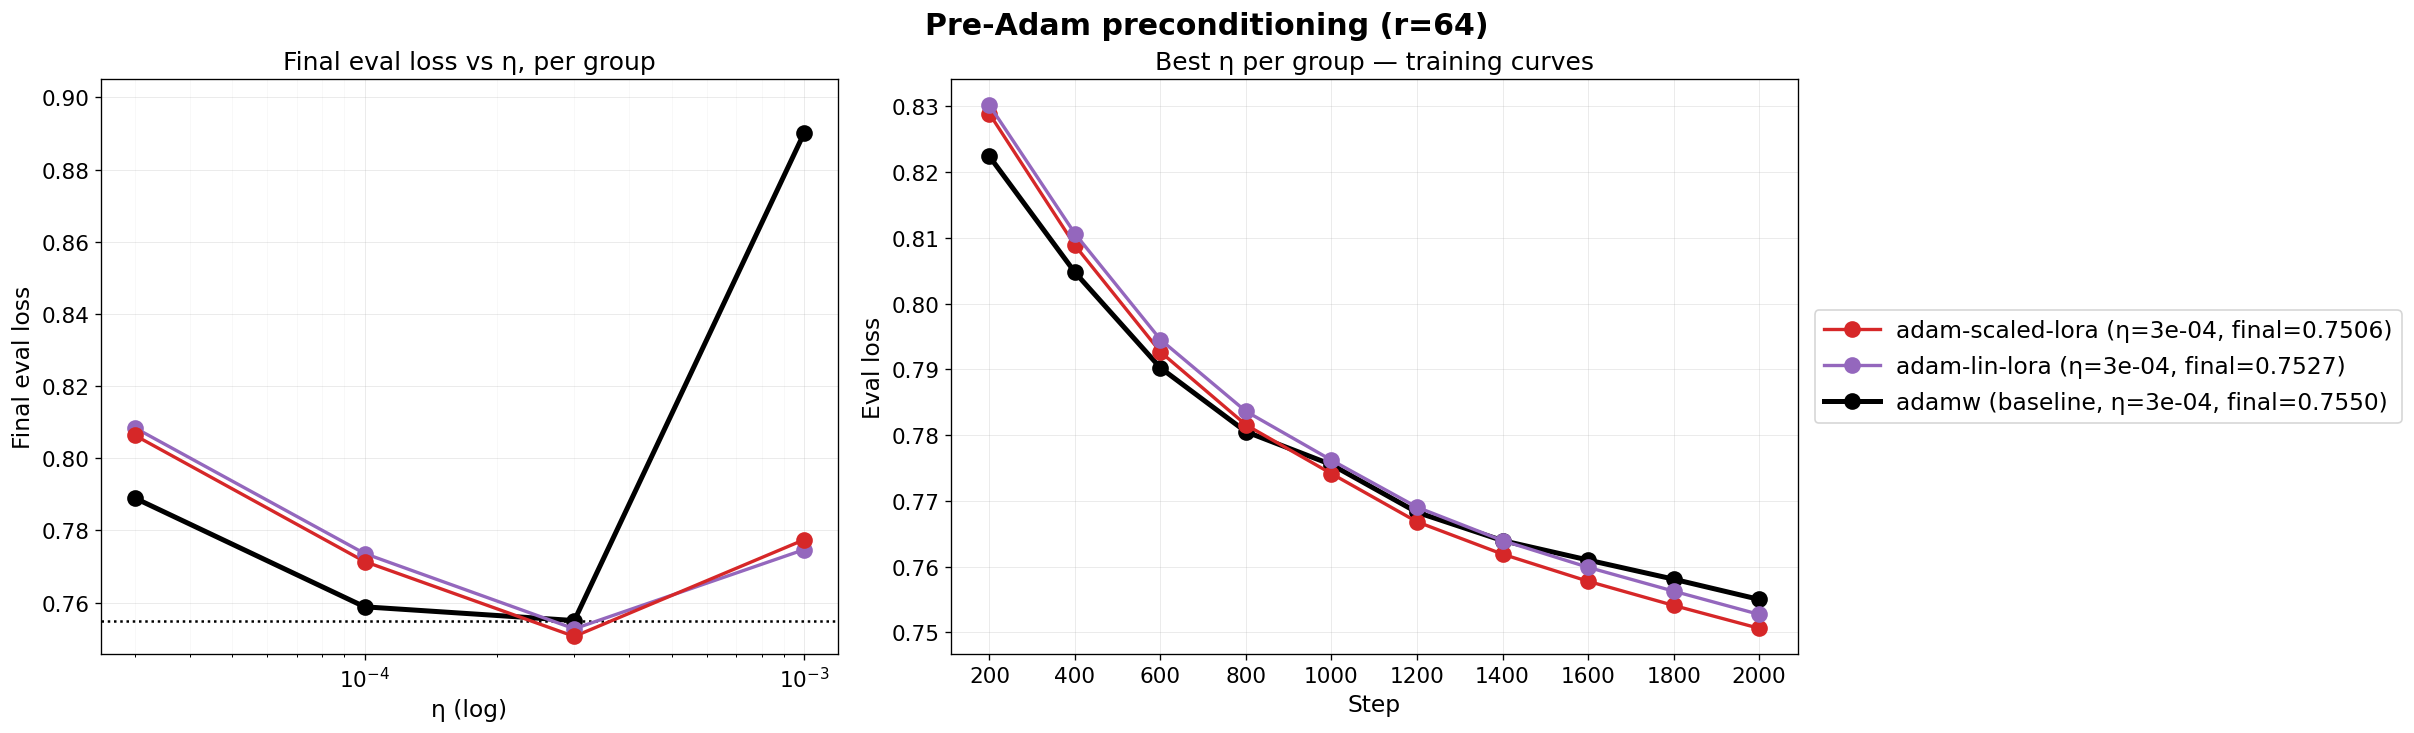

  [filtered partial from left panel] 1 run(s) below min_step=2000:
    adam-scaled-lora η=3e-05       step=1000 final-so-far=0.8137
  [clipped from left panel y_cap=0.898] 1 run(s):
    adamw η=1e-03 final=1.0116


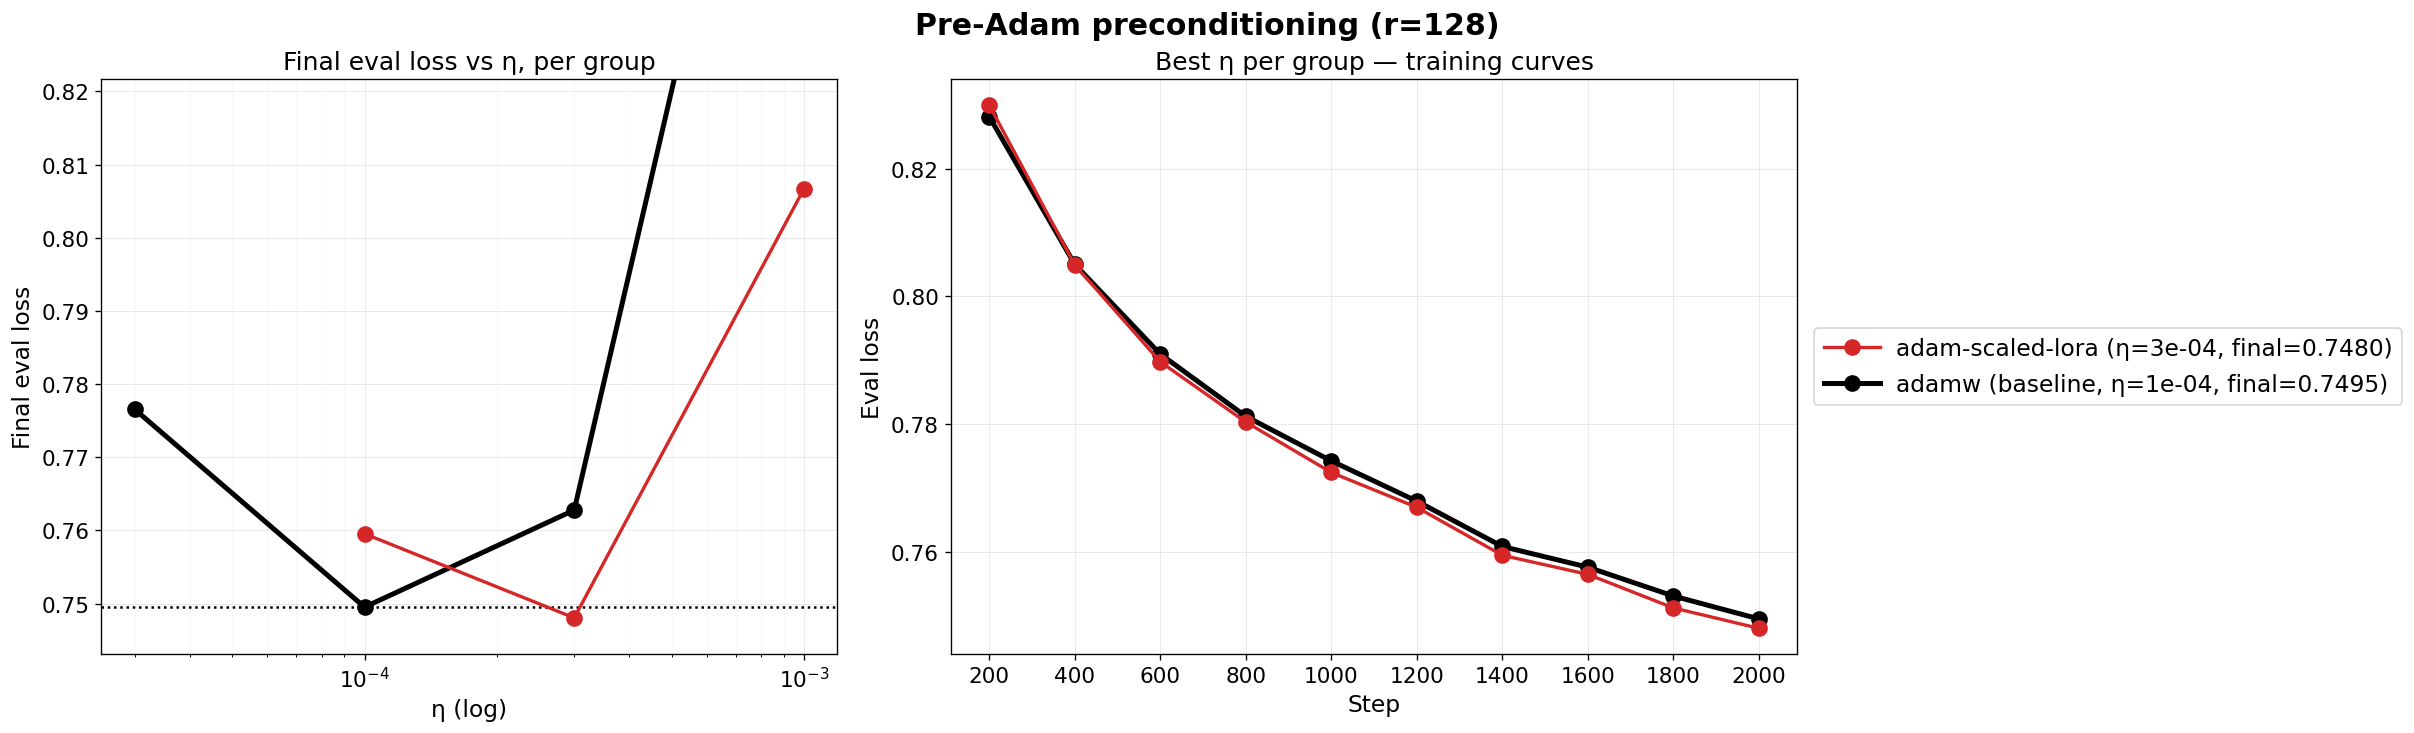

  [filtered partial from left panel] 1 run(s) below min_step=2000:
    adam-scaled-lora η=3e-05       step=400 final-so-far=0.8289
  [clipped from left panel y_cap=0.893] 1 run(s):
    adamw η=1e-03 final=1.2023


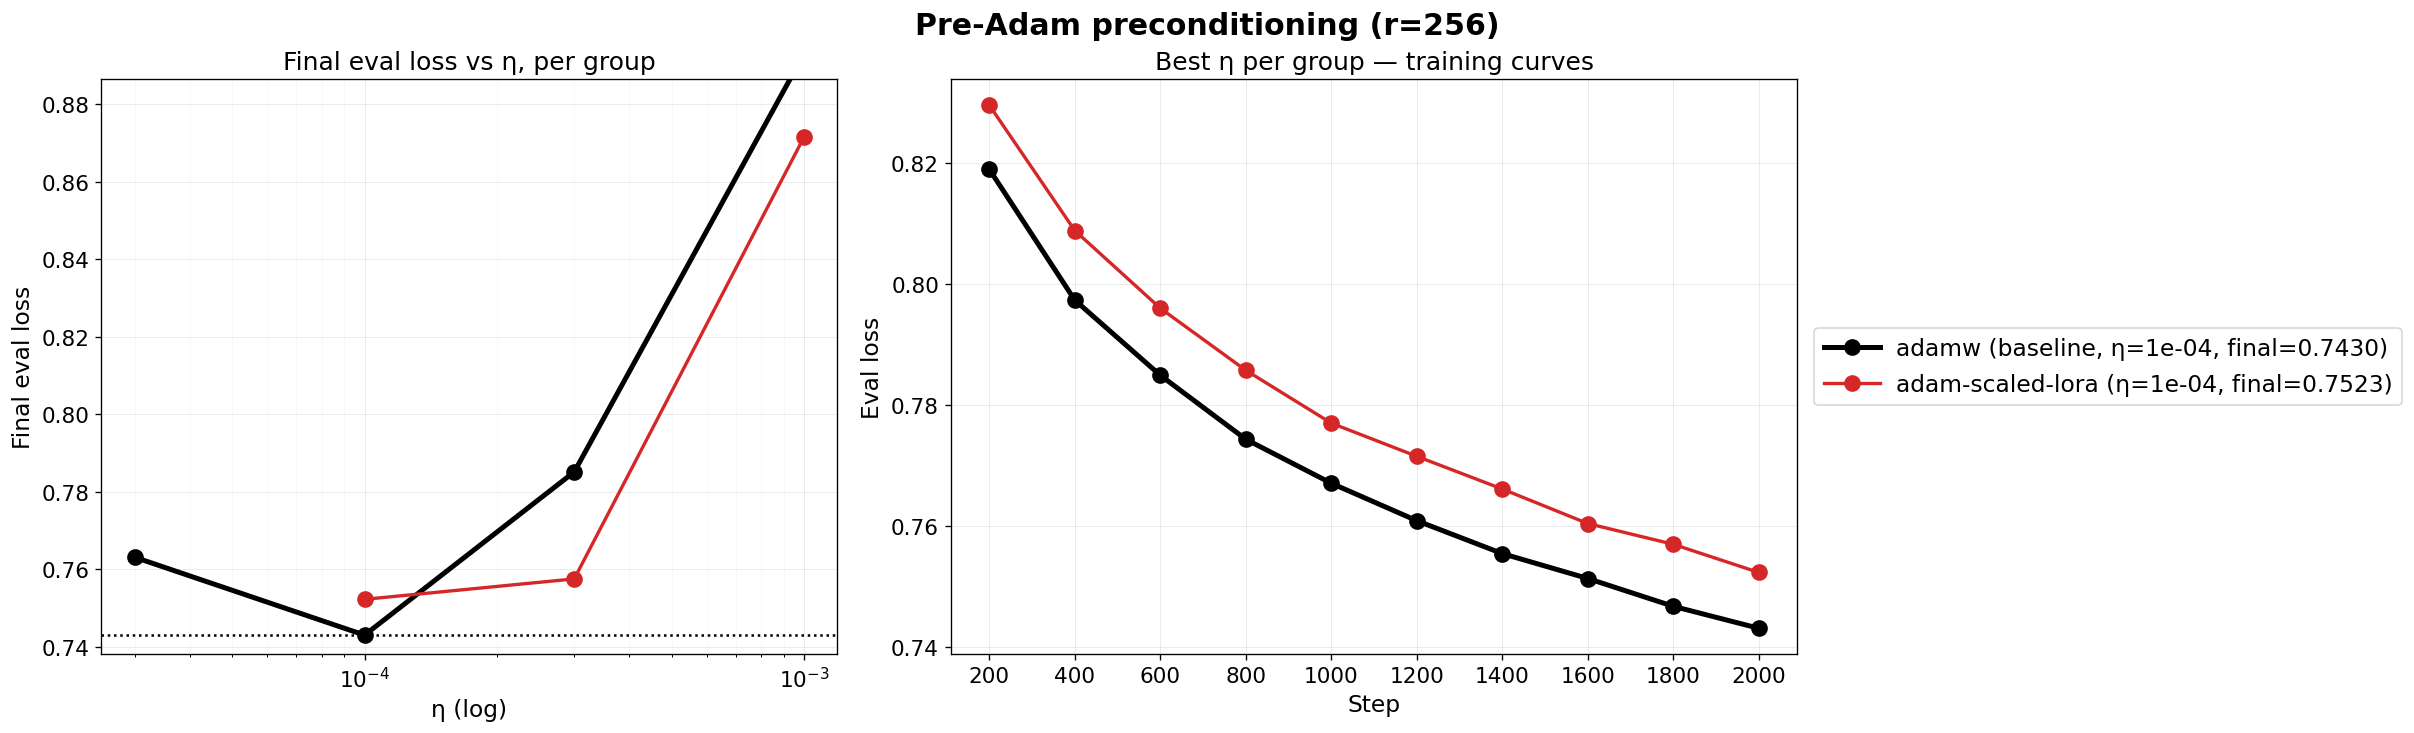

In [7]:
_FAMILY = {'adam-lin-lora', 'adam-scaled-lora', 'adamw'}

# One panel per rank present in ext_runs for this family. New ranks (r=128, r=256)
# appear automatically as their data lands without code changes.
_ranks = sorted({c["_lora_r"] for c, _ in ext_runs
                 if c["optimizer"] in _FAMILY
                 and float(c.get("lora_plus_multiplier", 1.0)) == 1.0})

for r in _ranks:
    _runs = [(c, e) for c, e in ext_runs
             if c["_lora_r"] == r and c["optimizer"] in _FAMILY
             and float(c.get("lora_plus_multiplier", 1.0)) == 1.0]
    if not _runs:
        continue
    standard_sweep_figure(
        _runs,
        group_key_fn=lambda c: c["optimizer"],
        color_map=OPTIM_COLORS,
        marker_map=OPTIM_MARKERS,
        reference_runs=_runs,
        suptitle=f"Pre-Adam preconditioning (r={r})",
    )
    plt.show()

### Adam → spectral/polar (the headline)

  [filtered diverged] adam-polar-product-lora η=1e-02 max=1.977 final=1.651
  [filtered diverged] adamw η=1e-02            max=9.009 final=6.937
  [filtered partial from left panel] 3 run(s) below min_step=2000:
    adam-muon-lora η=1e-04         step=500 final-so-far=1.0742
    adam-muon-lora η=3e-02         step=500 final-so-far=0.8920
    adam-muon-lora η=3e-04         step=500 final-so-far=0.9272
  [clipped from left panel y_cap=0.905] 2 run(s):
    adam-polar-product-lora η=3e-03 final=0.9997
    adamw η=3e-03 final=1.0223


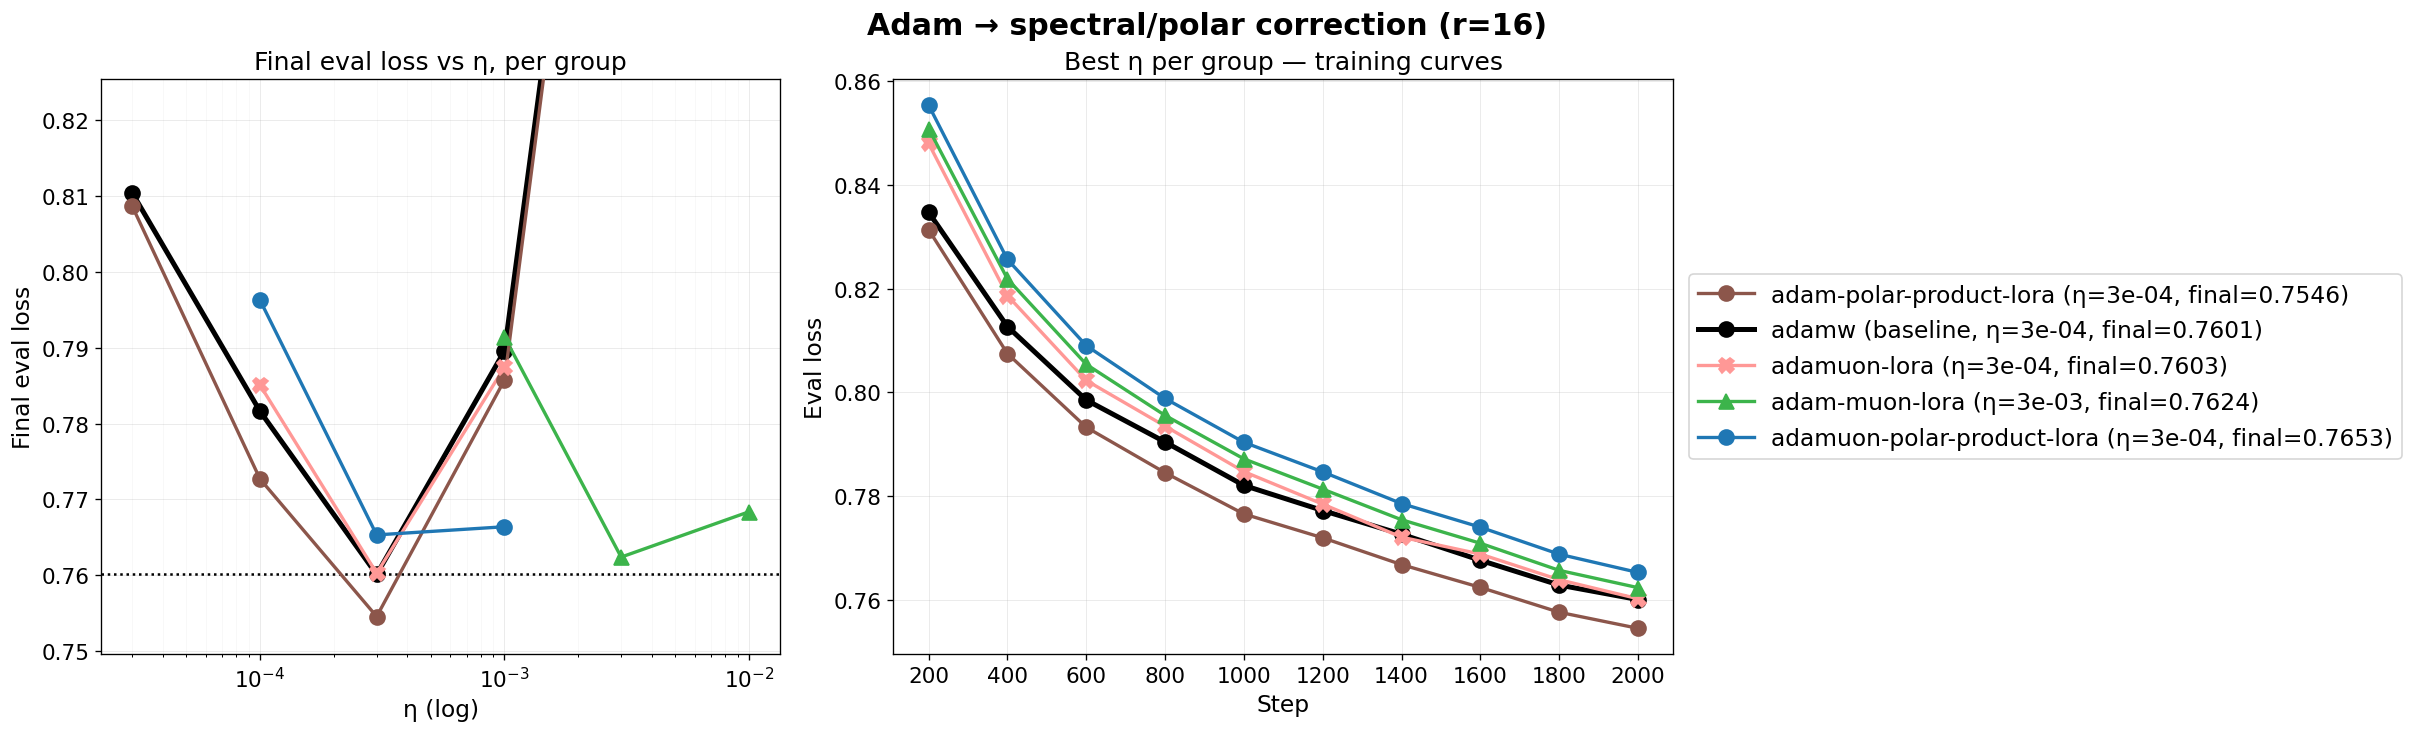

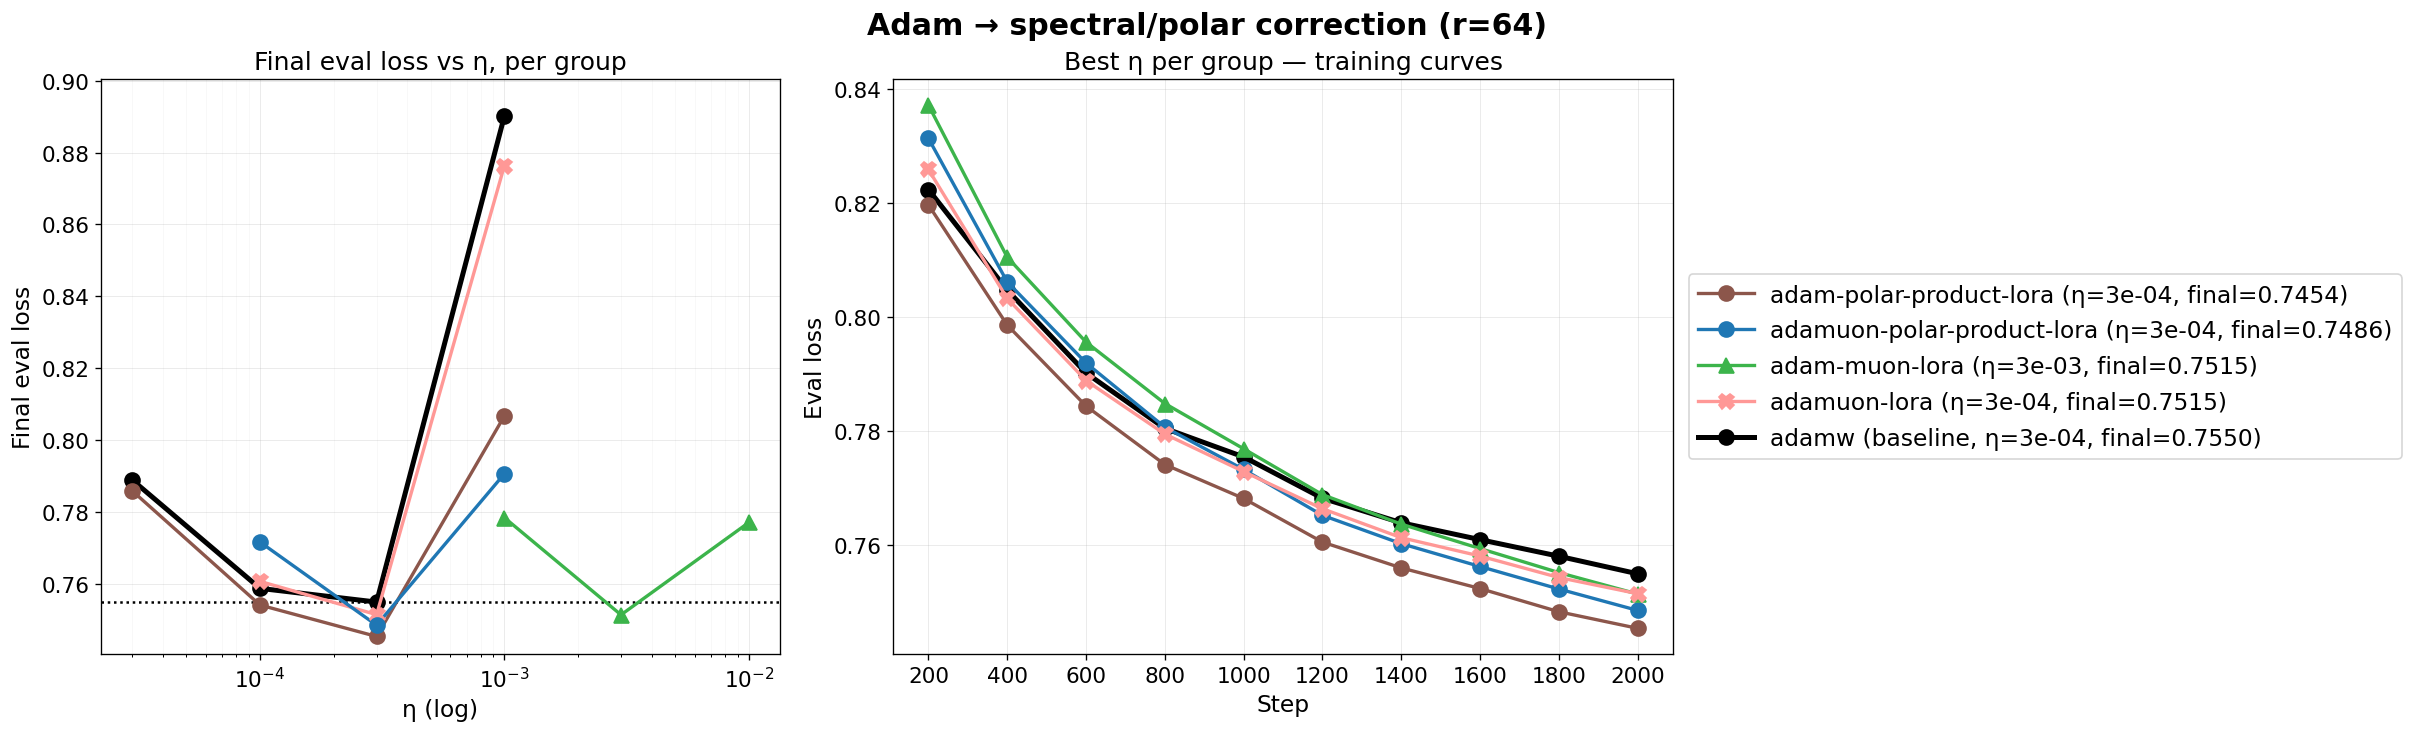

  [filtered partial from left panel] 1 run(s) below min_step=2000:
    adam-polar-product-lora η=3e-05 step=1600 final-so-far=0.7836
  [clipped from left panel y_cap=0.894] 1 run(s):
    adamw η=1e-03 final=1.0116


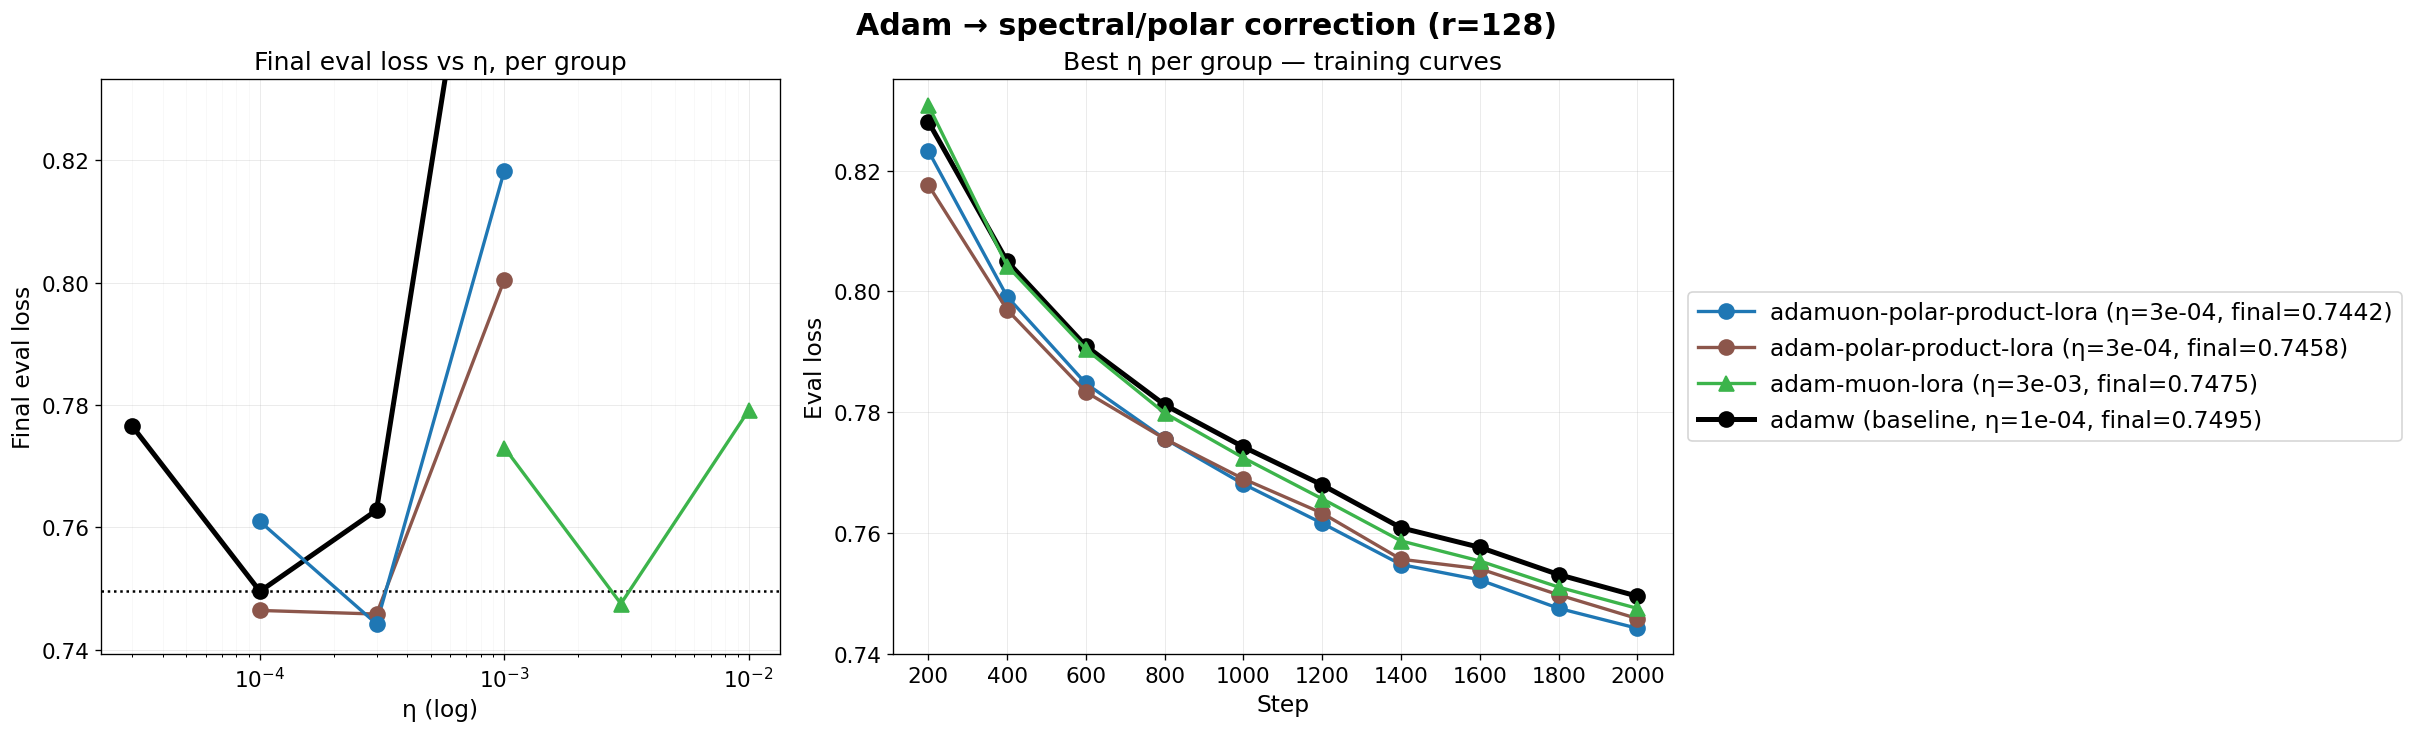

  [filtered partial from left panel] 1 run(s) below min_step=2000:
    adam-polar-product-lora η=3e-05 step=800 final-so-far=0.7986
  [clipped from left panel y_cap=0.891] 1 run(s):
    adamw η=1e-03 final=1.2023


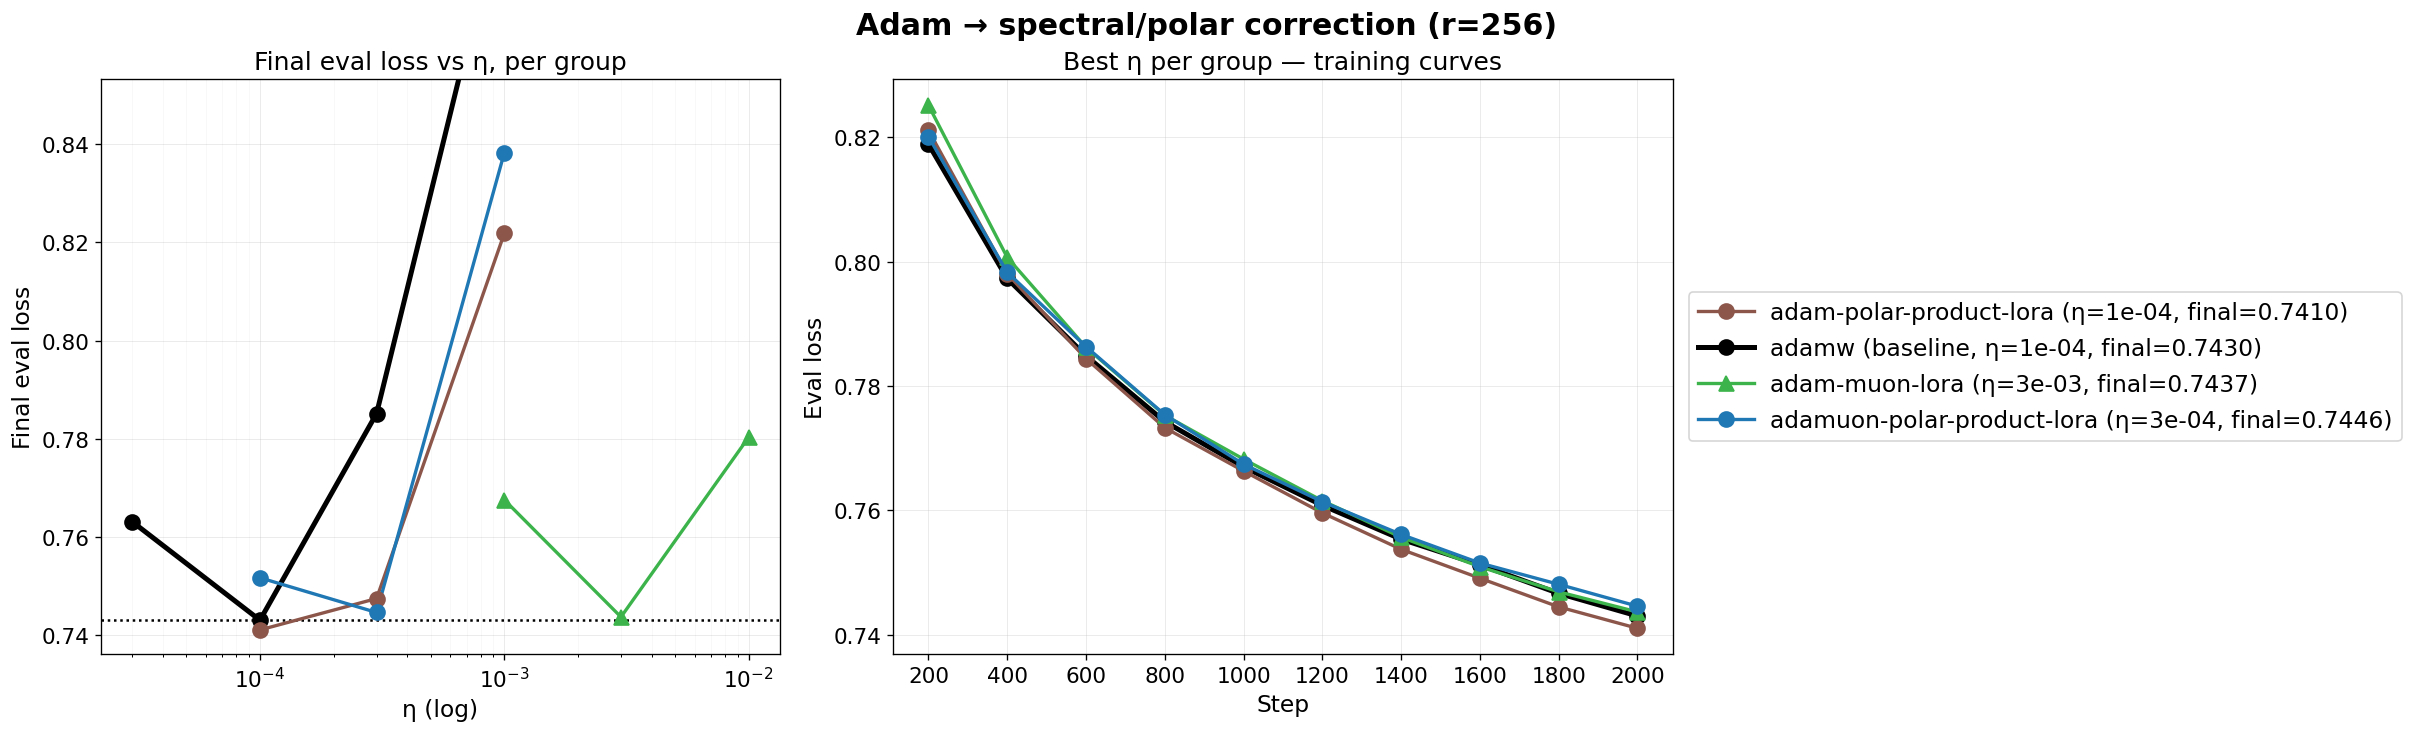

In [8]:
_FAMILY = {'adam-muon-lora', 'adam-polar-product-lora', 'adamuon-lora', 'adamuon-polar-product-lora', 'adamw'}

# One panel per rank present in ext_runs for this family.
_ranks = sorted({c["_lora_r"] for c, _ in ext_runs
                 if c["optimizer"] in _FAMILY
                 and float(c.get("lora_plus_multiplier", 1.0)) == 1.0})

for r in _ranks:
    _runs = [(c, e) for c, e in ext_runs
             if c["_lora_r"] == r and c["_lora_r"] >= 16 and c["optimizer"] in _FAMILY
             and float(c.get("lora_plus_multiplier", 1.0)) == 1.0]
    if not _runs:
        continue
    standard_sweep_figure(
        _runs,
        group_key_fn=lambda c: c["optimizer"],
        color_map=OPTIM_COLORS,
        marker_map=OPTIM_MARKERS,
        reference_runs=_runs,
        suptitle=f"Adam → spectral/polar correction (r={r})",
    )
    plt.show()

### No-Adam baselines (no per-coord v̂)

  [filtered diverged] adamw η=1e-02            max=9.009 final=6.937
  [clipped from left panel y_cap=0.910] 15 run(s):
    adamw η=3e-03 final=1.0223
    lin-lora η=3e-05 final=1.0375
    lin-lora η=1e-04 final=0.9594
    lin-lora η=3e-04 final=0.9231
    muon-lora η=3e-05 final=1.0015
    muon-lora η=3e-04 final=1.1844
    muon-lora η=1e-03 final=1.1658
    muon-lora η=3e-03 final=1.0672
    muon-lora η=1e-02 final=0.9499
    muon-lora η=3e-02 final=1.1452
    scaled-lora η=3e-05 final=1.0945
    scaled-lora η=1e-04 final=0.9982
    scaled-lora η=3e-04 final=0.9514
    scaled-lora η=1e-03 final=0.9200
    scaled-lora η=3e+01 final=1.1793


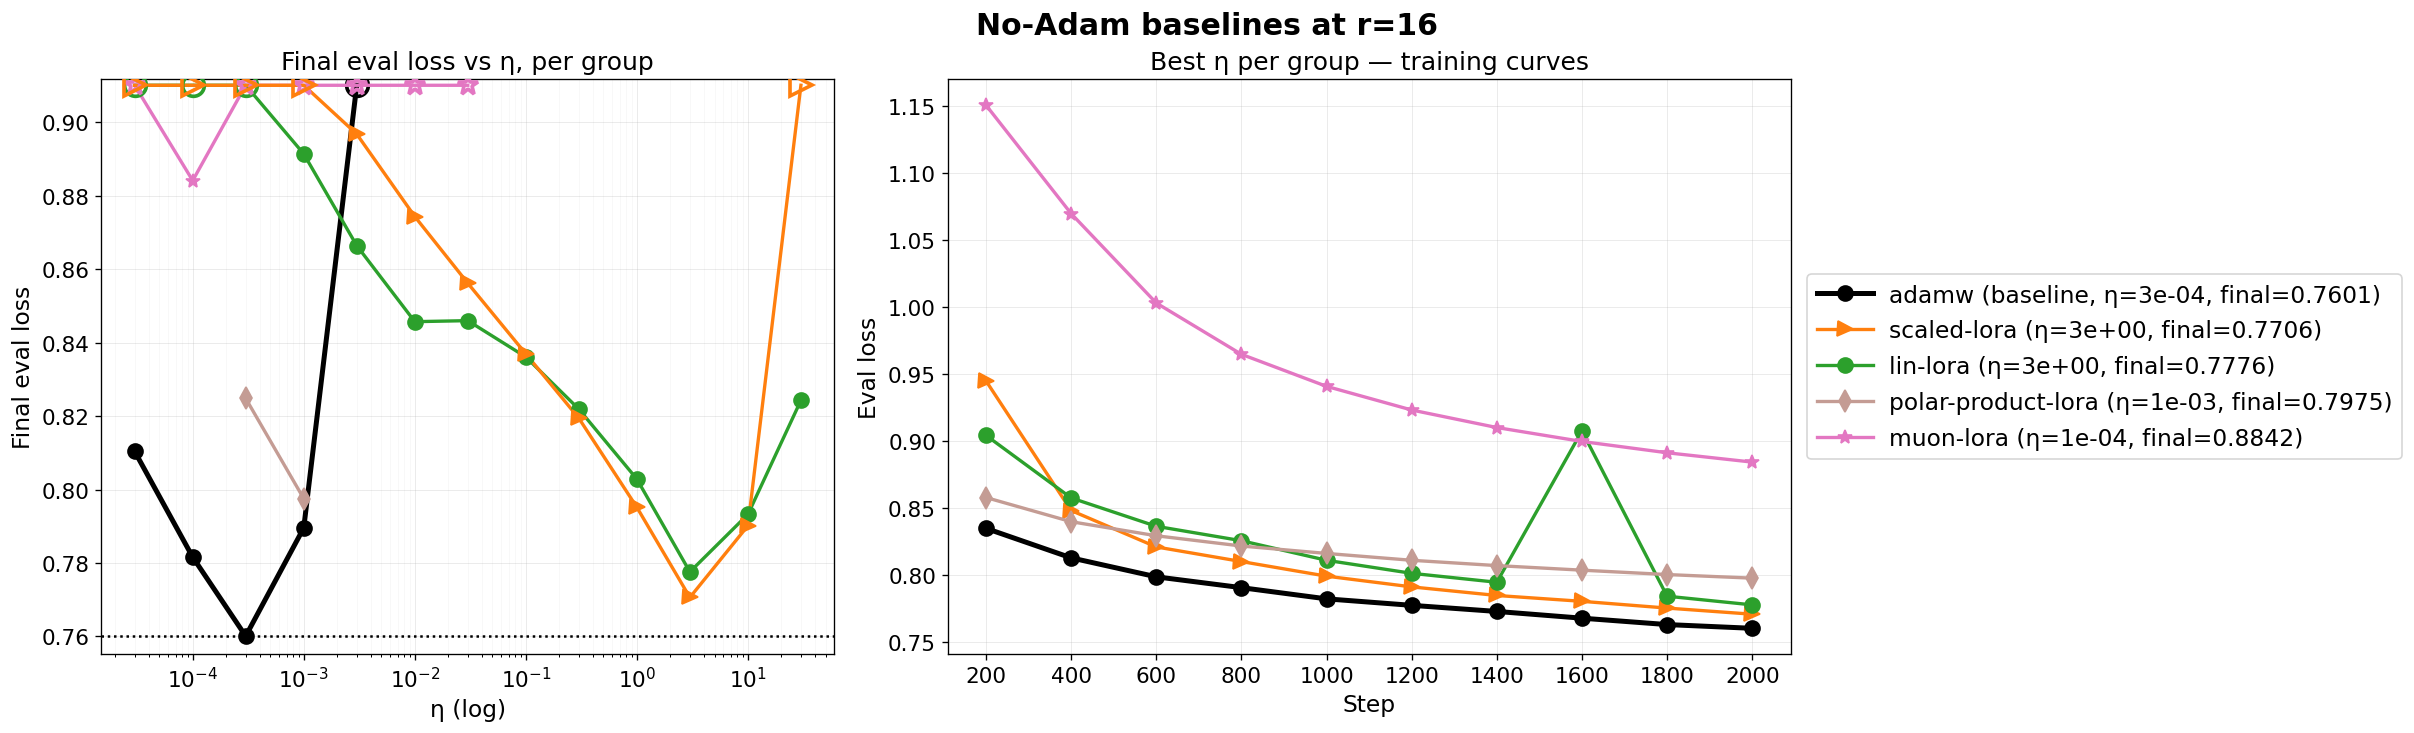

In [9]:
# No-Adam baselines at r=16
_FAMILY = {'adamw', 'muon-lora', 'polar-product-lora', 'lin-lora', 'scaled-lora'}
_runs = [(c, e) for c, e in ext_runs if c["_lora_r"] == 16 and c["optimizer"] in _FAMILY and float(c.get("lora_plus_multiplier", 1.0)) == 1.0]
standard_sweep_figure(
    _runs,
    group_key_fn=lambda c: c["optimizer"],
    color_map=OPTIM_COLORS,
    marker_map=OPTIM_MARKERS,
    reference_runs=_runs,
    suptitle="No-Adam baselines",
)
plt.show()


### Post-Adam corrections (Adam → geometry, falsified family)

  [filtered diverged] adamw η=1e-02            max=9.009 final=6.937
  [clipped from left panel y_cap=0.907] 3 run(s):
    adam-scaled-lora-matrix η=3e-05 final=0.9255
    adamw η=3e-03 final=1.0223
    muon-adam-lora η=3e-03 final=1.0169


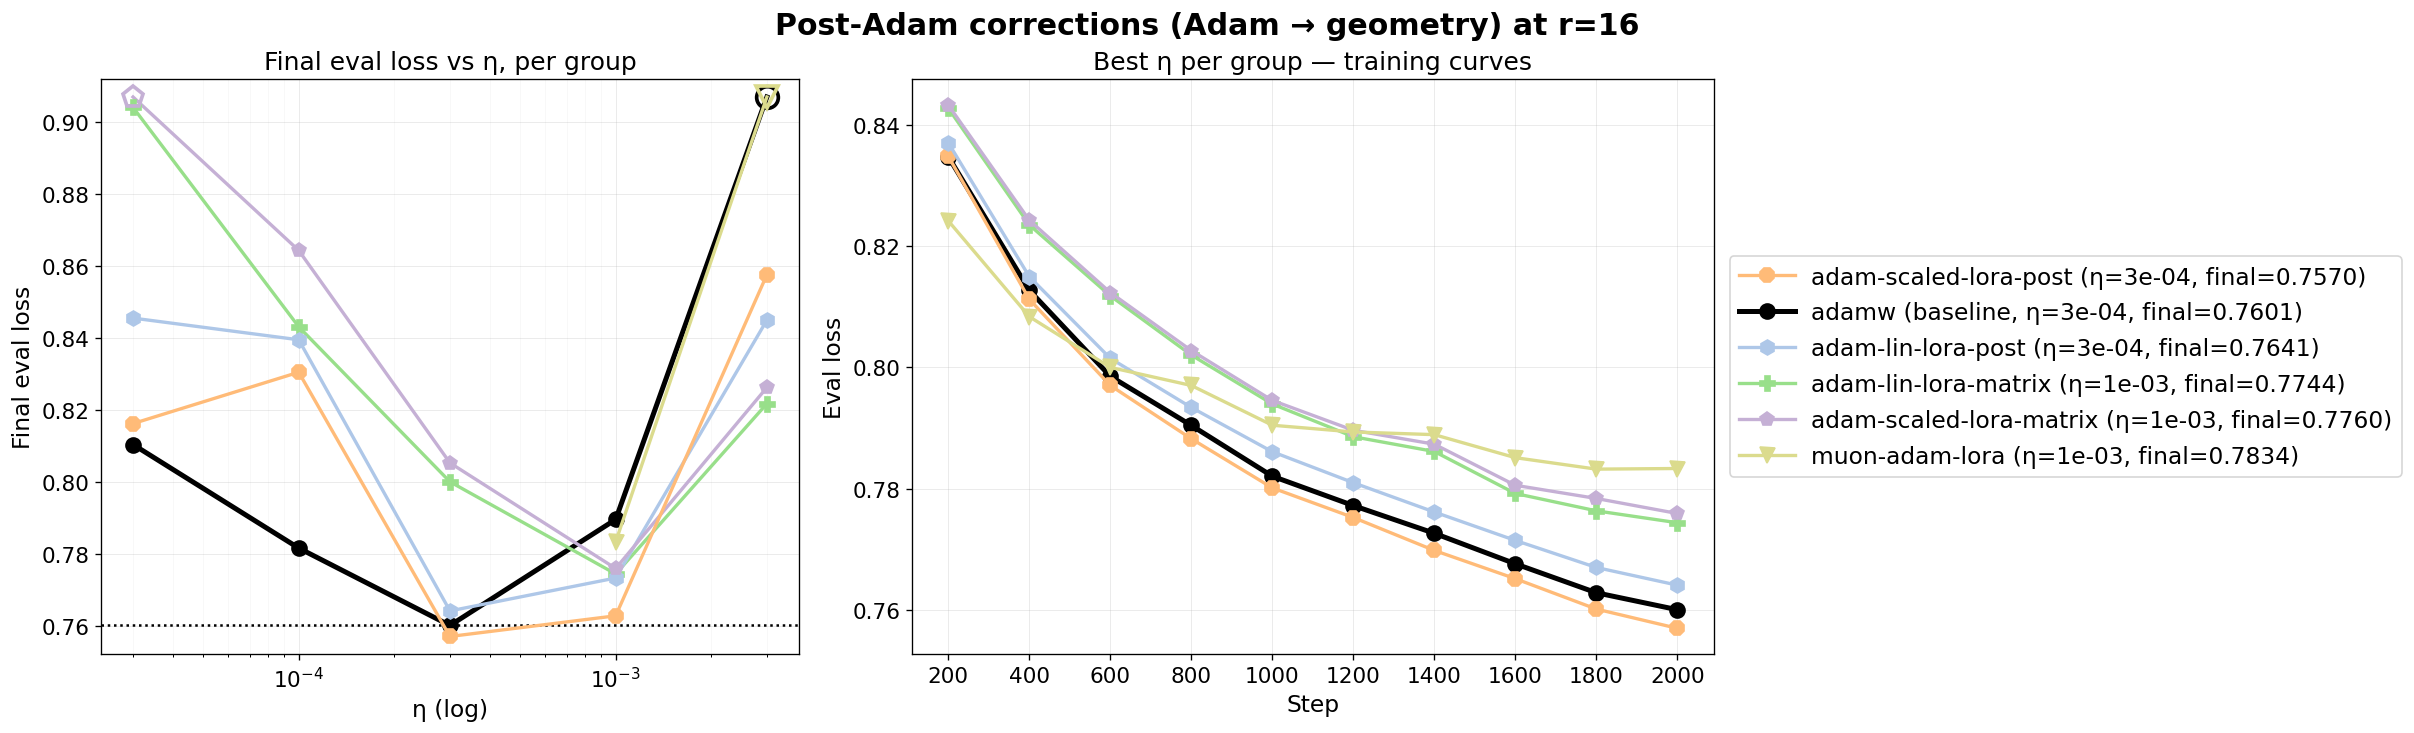

In [10]:
# Post-Adam corrections at r=16
_FAMILY = {'adamw', 'adam-lin-lora-post', 'adam-scaled-lora-post', 'adam-lin-lora-matrix', 'adam-scaled-lora-matrix', 'muon-adam-lora'}
_runs = [(c, e) for c, e in ext_runs if c["_lora_r"] == 16 and c["optimizer"] in _FAMILY and float(c.get("lora_plus_multiplier", 1.0)) == 1.0]
standard_sweep_figure(
    _runs,
    group_key_fn=lambda c: c["optimizer"],
    color_map=OPTIM_COLORS,
    marker_map=OPTIM_MARKERS,
    reference_runs=_runs,
    suptitle="Post-Adam corrections (Adam → geometry)",
)
plt.show()

### Other variants (uninformative reference)

Per-coord K-FAC family, GaLore, and gauge-invariant ProductMuon. Synthesis treats these as uninformative for the headline question — all 0.03+ above AdamW. Plotted for completeness so no optimizer is silently skipped.

  [filtered diverged] adamw η=1e-02            max=9.009 final=6.937
  [filtered diverged] diag-scaled-lora η=1e+00 max=9.292 final=6.136
  [filtered diverged] diag-scaled-lora η=3e+00 max=12.436 final=8.034
  [filtered diverged] galore-adamw η=1e-02     max=1.653 final=1.636
  [filtered diverged] kron-grad-lora η=3e-02   max=9.879 final=4.922
  [filtered partial from left panel] 9 run(s) below min_step=2000:
    adam-product-muon-lora η=1e-02 step=200 final-so-far=1.0368
    adam-product-muon-lora η=1e-03 step=200 final-so-far=0.8282
    adam-product-muon-lora η=3e-03 step=200 final-so-far=0.8492
    adam-product-muon-lora η=3e-04 step=200 final-so-far=0.8455
    product-muon-lora η=1e-02      step=500 final-so-far=0.8093
    product-muon-lora η=1e-03      step=500 final-so-far=0.8621
    product-muon-lora η=3e-03      step=500 final-so-far=0.8277
    product-muon-lora η=3e-04      step=500 final-so-far=0.9248
    psi-lora η=1e-02               step=400 final-so-far=0.9433
  [clipped 

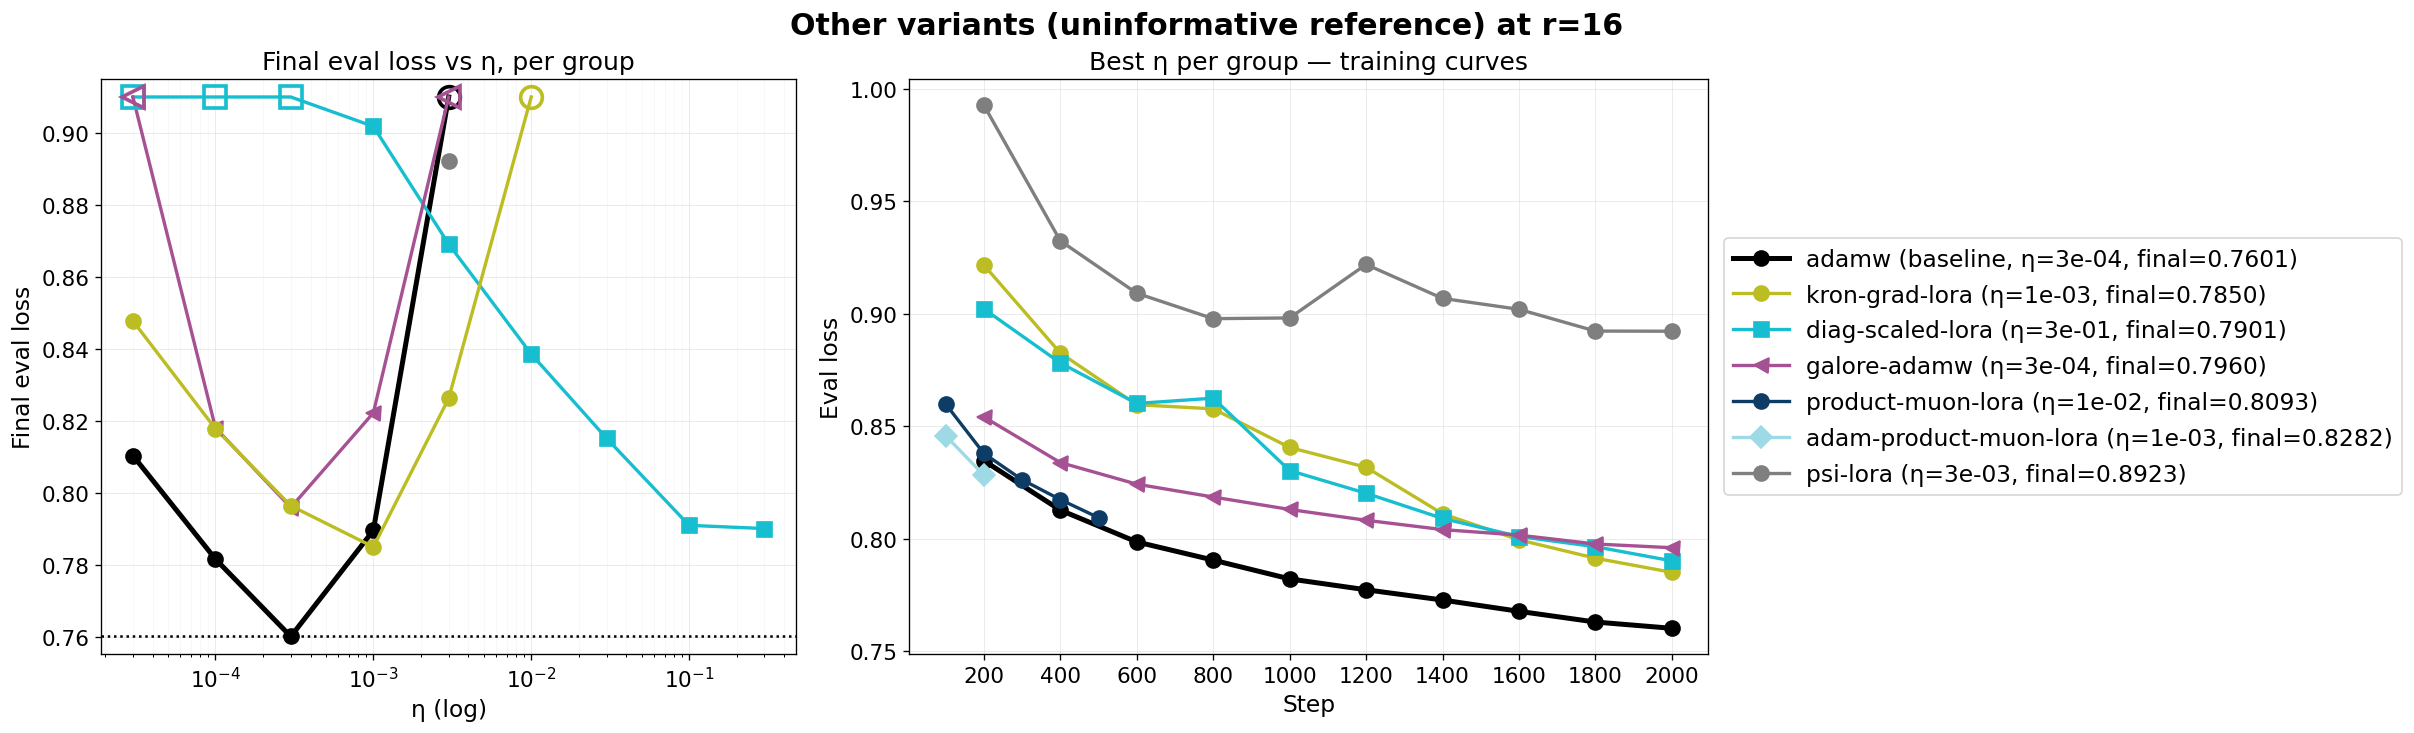

In [11]:
# Other variants at r=16 — uninformative low-performers
_FAMILY = {'adamw', 'product-muon-lora', 'adam-product-muon-lora', 'diag-scaled-lora', 'kron-grad-lora', 'psi-lora', 'galore-adamw'}
_runs = [(c, e) for c, e in ext_runs if c["_lora_r"] == 16 and c["optimizer"] in _FAMILY and float(c.get("lora_plus_multiplier", 1.0)) == 1.0]
standard_sweep_figure(
    _runs,
    group_key_fn=lambda c: c["optimizer"],
    color_map=OPTIM_COLORS,
    marker_map=OPTIM_MARKERS,
    reference_runs=_runs,
    suptitle="Other variants (uninformative reference)",
)
plt.show()

## Muon-LoRA variants — beat AdamW campaign

Hypothesis-driven sweep:
- **Tier 1 (`muon_loraplus_2k`)**: H1 — LoRA+ asymmetry on B's lr (m ∈ {4, 16}). Baseline m=1 reused from earlier groups.
- **Tier 2 (`muon_nsoff_2k`)**: H3 sanity — `--muon_ns_steps 0` ⇒ momentum SGD (NS disabled). If matches Muon-LoRA, the orthogonalization is irrelevant.
- **Tier 3 (`product_muon_2k`)**: H2 — `ProductMuonLoRA`, NS on the merged-direction proxy `D = (1/scale)·m_B·(AAᵀ+δI)⁻¹·A` then Sylvester-recovered. Theory: `docs/theory/main.tex` line 622+.
- **Tier 4 (`adam_muon_2k`)**: H4 — `AdamMuonLoRA`, NS on Adam's m̂/(√v̂+ε) direction.

Reference frontiers (single-seed, from earlier sweeps): AdamW @ 0.7579, adam-lin-lora @ 0.7564. Goal: come in below both. Multi-seed verification deferred.

In [12]:
def _stamp_muon_meta(cfg, group):
    """Inject muon_ns_steps from --muon_ns_steps (default 5)."""
    v = parse_flag(cfg.get("command", ""), "--muon_ns_steps")
    cfg["muon_ns_steps"] = int(v) if v is not None else 5

# muon_ns_steps is computed by cfg_postprocess (parsed from --muon_ns_steps),
# so the ns!=0 filter happens after load_runs rather than via `where`.
_muon_runs_all = load_runs(
    where={"optimizer": ["muon-lora", "product-muon-lora", "adam-muon-lora"]},
    key_axes=("optimizer", "lr", "lora_plus_multiplier", "muon_ns_steps", "lora_r"),
    cfg_postprocess=_stamp_muon_meta,
    logs_root="../logs",
)
muon_runs = [(c, e) for c, e in _muon_runs_all if c["muon_ns_steps"] != 0]

print(f"Loaded {len(muon_runs)} Muon-family runs")
for cfg, evs in sorted(muon_runs, key=lambda x: (x[0]["optimizer"], x[0]["muon_ns_steps"],
                                                  x[0]["lora_plus_multiplier"], x[0]["lr"])):
    flag = " DIVERGED" if max_loss(evs) >= DIVERGE_THRESHOLD else ""
    print(f"  {cfg['optimizer']:<18s}  η={cfg['lr']:.0e}  "
          f"m={float(cfg['lora_plus_multiplier']):>4.1f}  "
          f"ns={cfg['muon_ns_steps']}  final={evs[-1]['eval_loss']:.4f}{flag}")

Loaded 51 Muon-family runs
  adam-muon-lora      η=1e-04  m= 1.0  ns=5  final=1.0742
  adam-muon-lora      η=3e-04  m= 1.0  ns=5  final=0.9272
  adam-muon-lora      η=1e-03  m= 1.0  ns=5  final=0.7730
  adam-muon-lora      η=1e-03  m= 1.0  ns=5  final=0.7675
  adam-muon-lora      η=1e-03  m= 1.0  ns=5  final=0.7914
  adam-muon-lora      η=1e-03  m= 1.0  ns=5  final=0.7785
  adam-muon-lora      η=3e-03  m= 1.0  ns=5  final=0.7475
  adam-muon-lora      η=3e-03  m= 1.0  ns=5  final=0.7437
  adam-muon-lora      η=3e-03  m= 1.0  ns=5  final=0.7624
  adam-muon-lora      η=3e-03  m= 1.0  ns=5  final=0.7515
  adam-muon-lora      η=1e-02  m= 1.0  ns=5  final=0.7791
  adam-muon-lora      η=1e-02  m= 1.0  ns=5  final=0.7803
  adam-muon-lora      η=1e-02  m= 1.0  ns=5  final=0.7684
  adam-muon-lora      η=1e-02  m= 1.0  ns=5  final=0.7771
  adam-muon-lora      η=3e-02  m= 1.0  ns=5  final=0.8920
  adam-muon-lora      η=1e-04  m= 4.0  ns=5  final=0.8262
  adam-muon-lora      η=1e-04  m= 4.0  ns=5  

  [filtered partial from left panel] 13 run(s) below min_step=2000:
    adam-muon η=1e-04              step=500 final-so-far=1.0742
    adam-muon η=3e-02              step=500 final-so-far=0.8920
    adam-muon η=3e-04              step=500 final-so-far=0.9272
    adam-muon+m=4 η=1e-04          step=500 final-so-far=0.9340
    adam-muon+m=4 η=3e-04          step=500 final-so-far=0.8644
    product-muon η=1e-02           step=500 final-so-far=0.8093
    product-muon η=1e-03           step=500 final-so-far=0.8621
    product-muon η=3e-03           step=500 final-so-far=0.8277
    product-muon η=3e-04           step=500 final-so-far=0.9248
    product-muon+m=4 η=1e-02       step=500 final-so-far=0.8567
    product-muon+m=4 η=1e-03       step=500 final-so-far=0.8267
    product-muon+m=4 η=3e-03       step=500 final-so-far=0.8166
    product-muon+m=4 η=3e-04       step=500 final-so-far=0.8581
  [clipped from left panel y_cap=0.906] 5 run(s):
    adam-muon+m=4 η=3e-02 final=1.2751
    muon η=

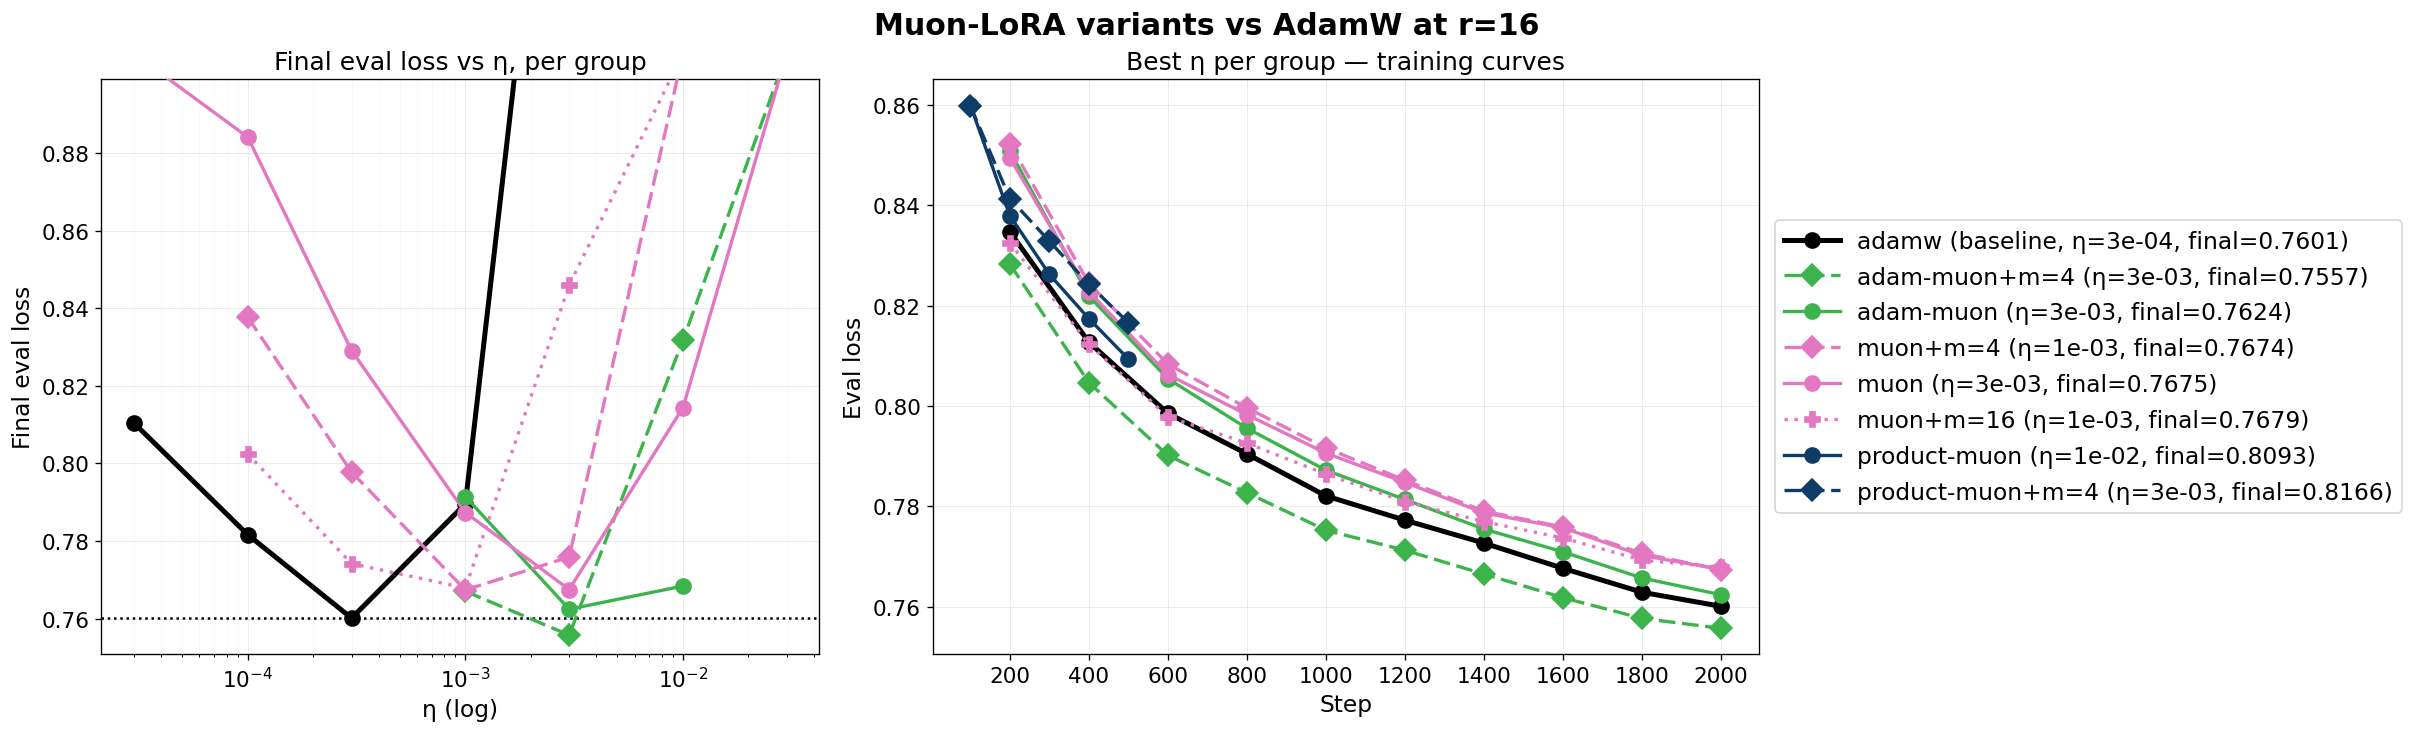

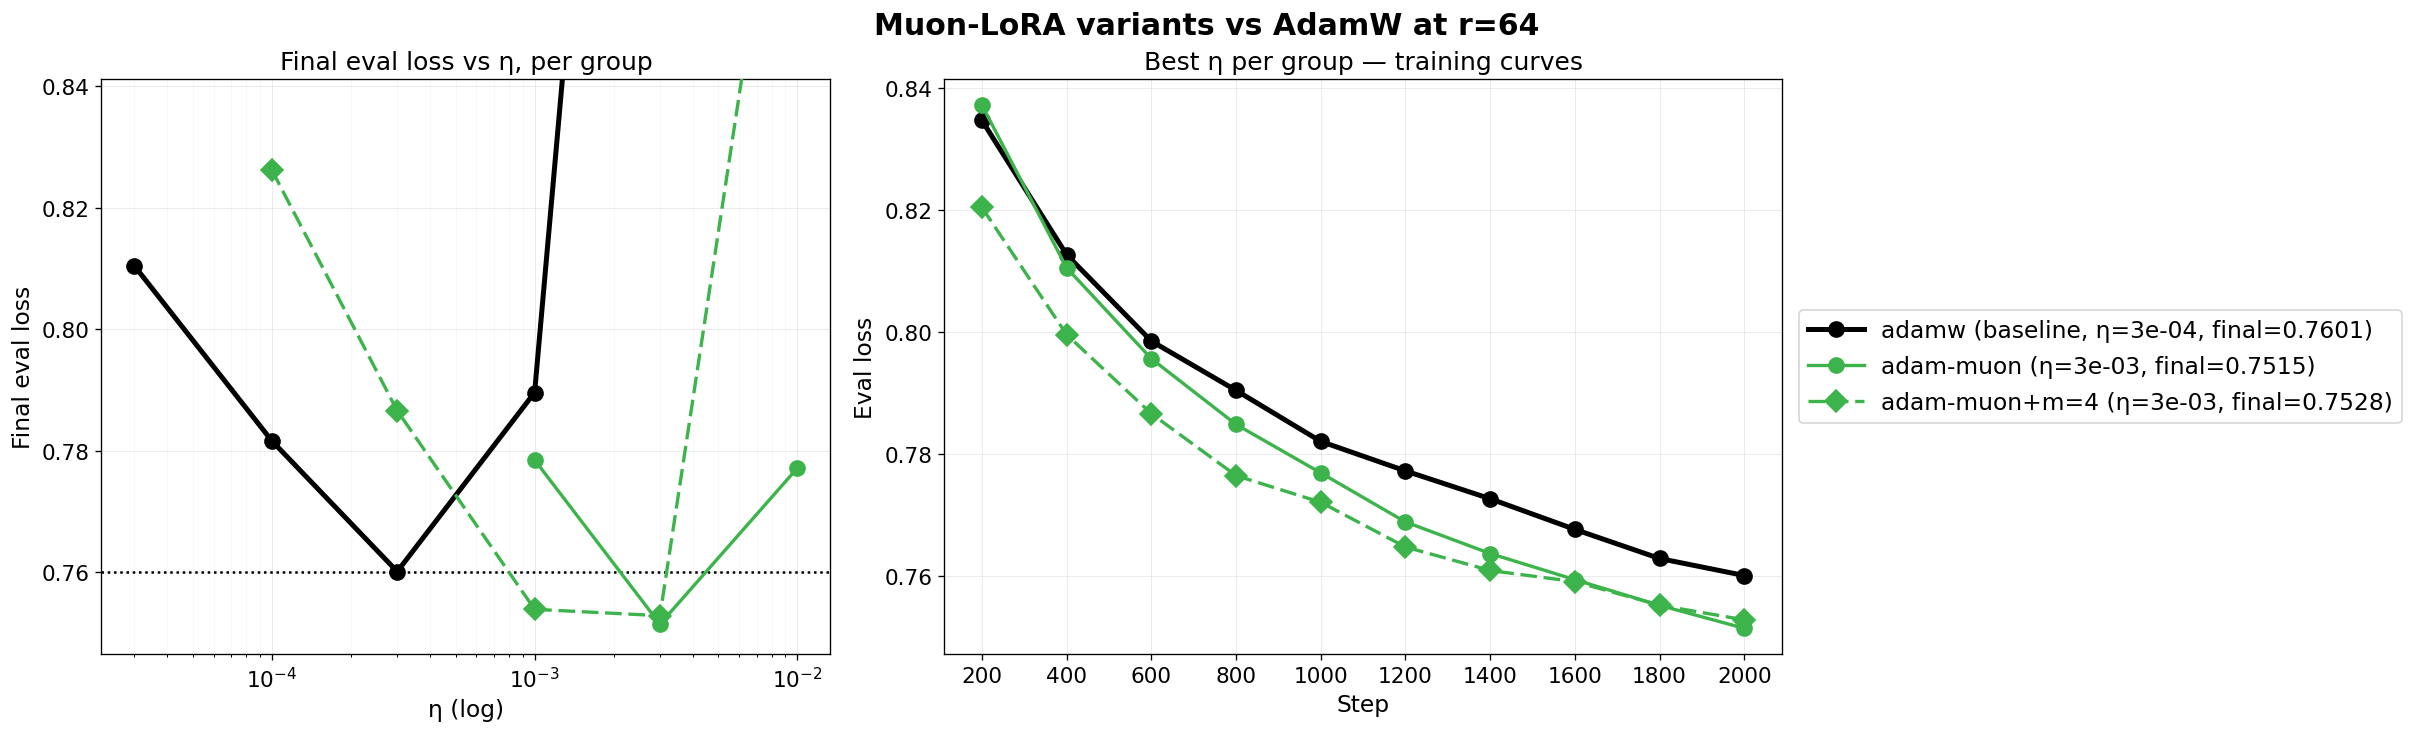

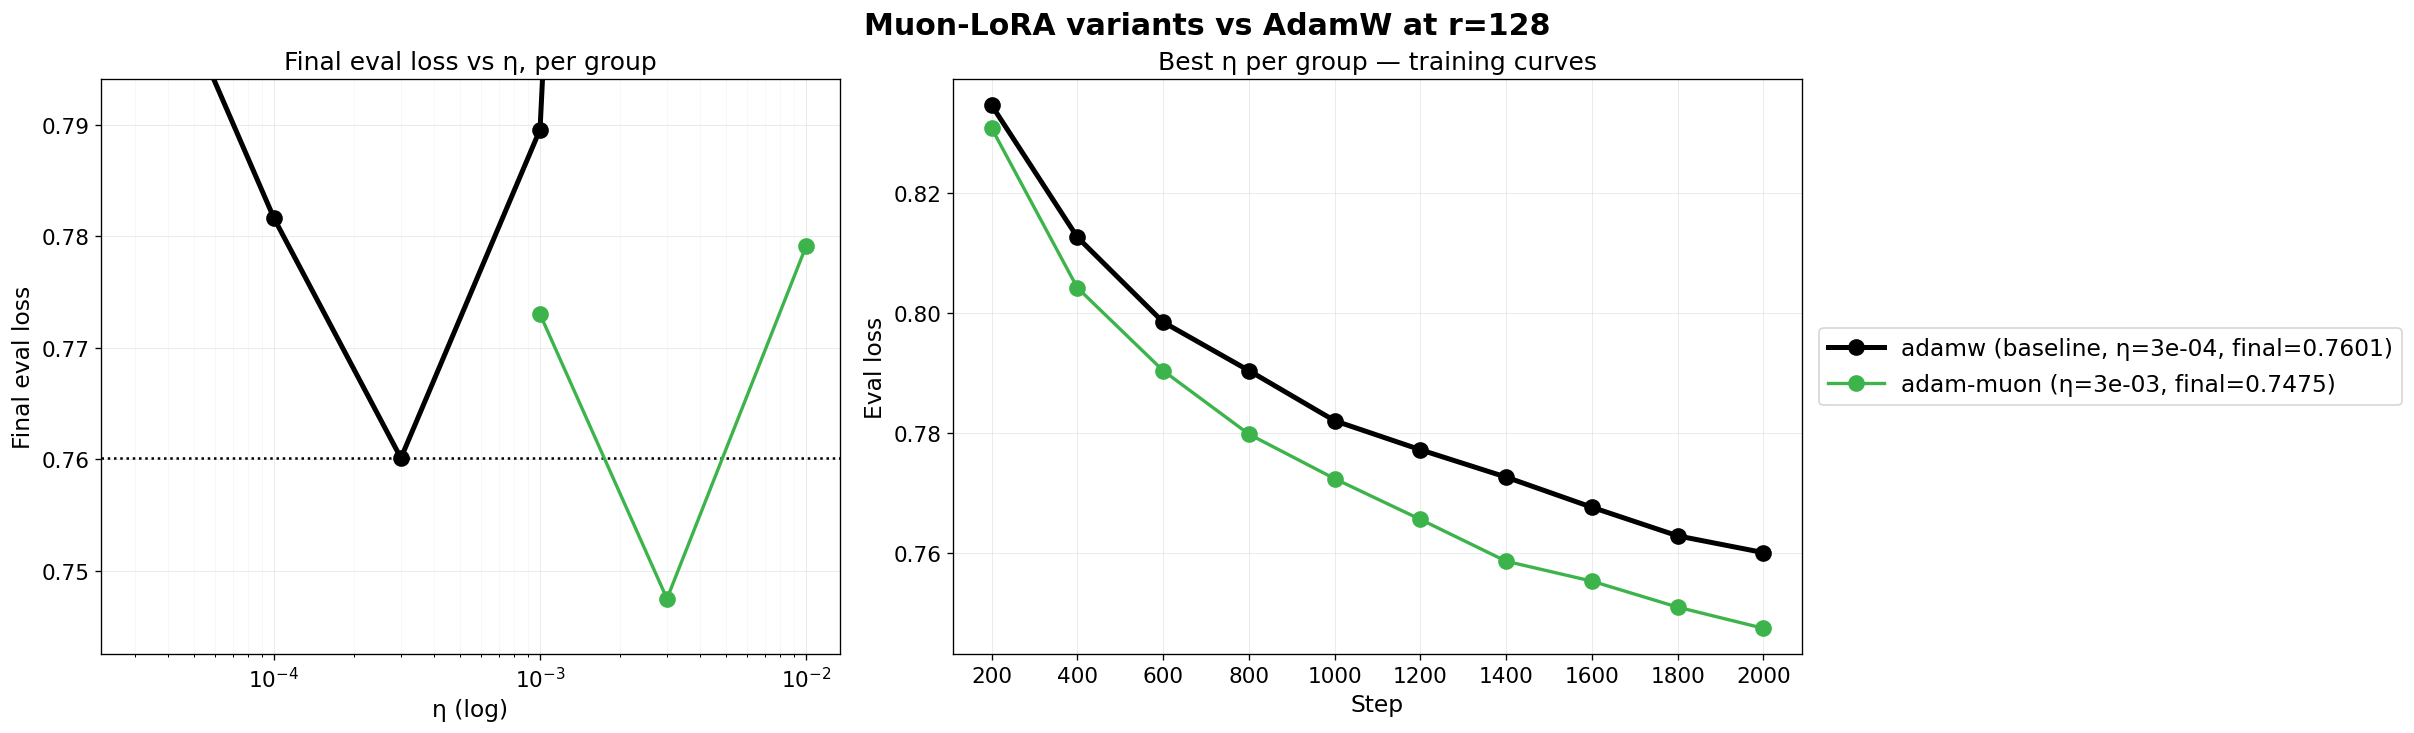

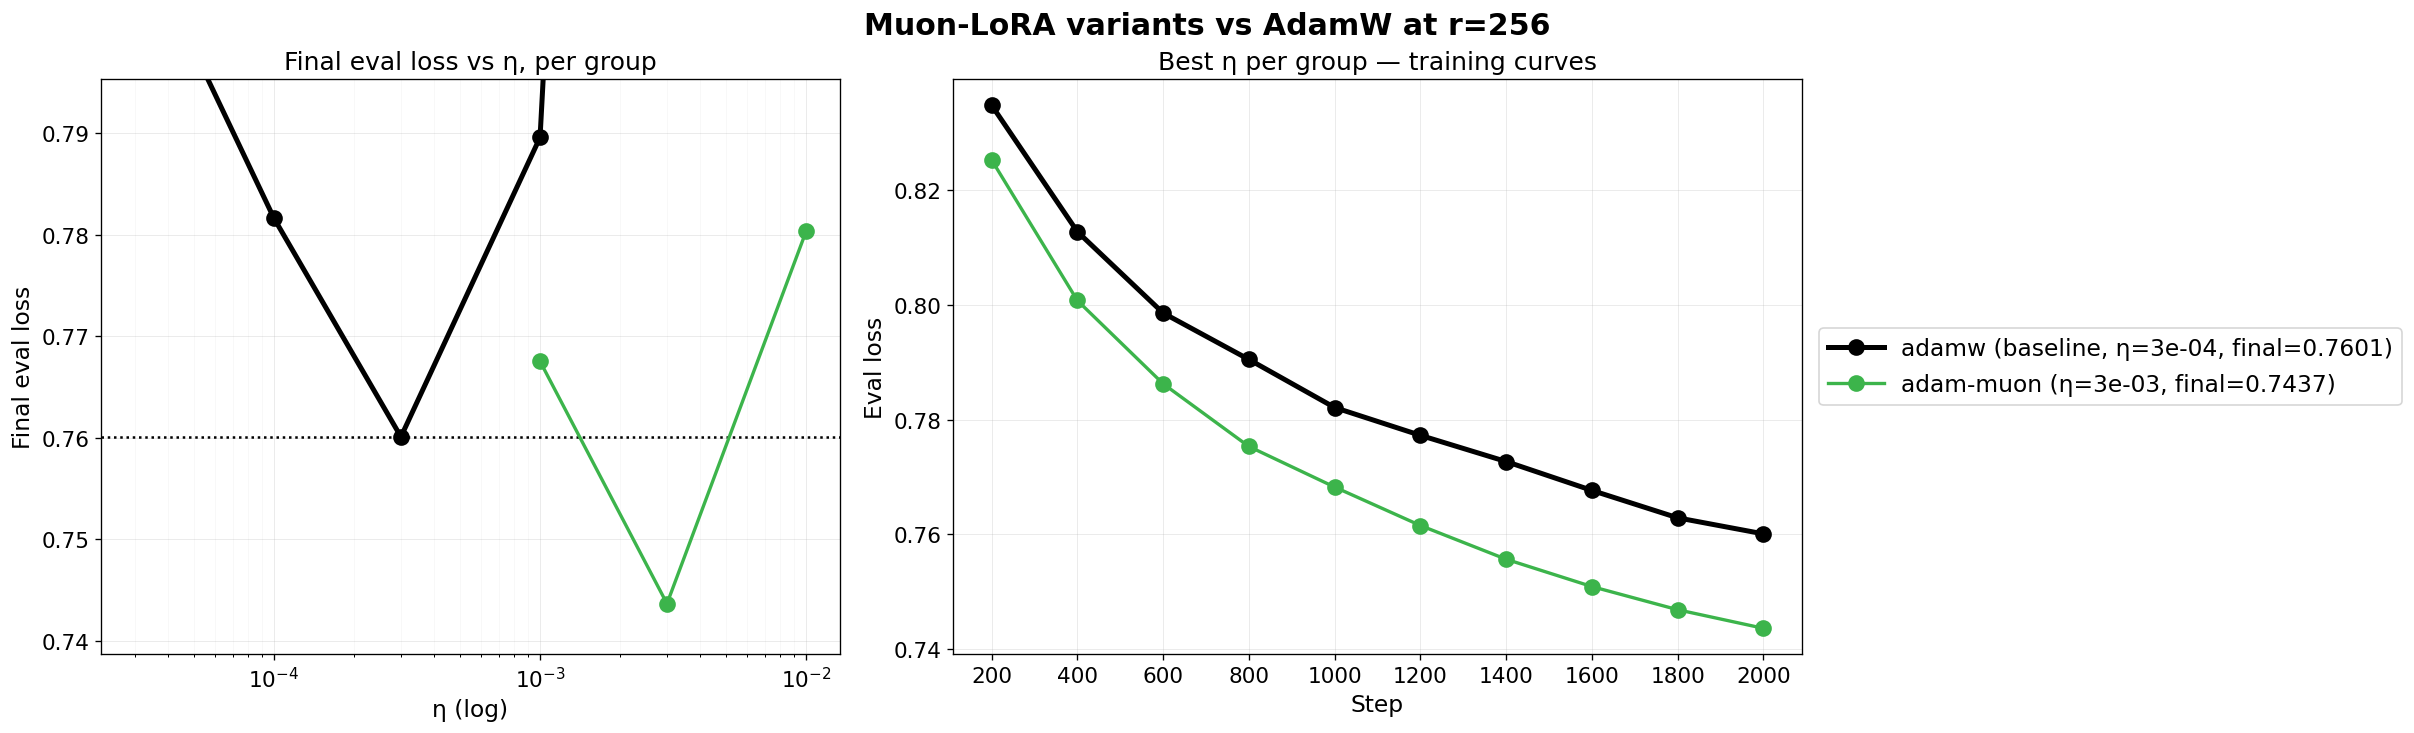

In [13]:
def _muon_variant(cfg):
    opt = cfg["optimizer"]
    m = float(cfg.get("lora_plus_multiplier", 1.0))
    ns = cfg.get("muon_ns_steps", 5)
    base = {"muon-lora": "muon", "product-muon-lora": "product-muon",
            "adam-muon-lora": "adam-muon"}[opt]
    parts = [base]
    if m != 1.0: parts.append(f"m={int(m)}")
    if ns == 0:  parts.append("ns=0")
    return "+".join(parts)

# standard_sweep_figure auto-splits per rank when runs span multiple ranks.
standard_sweep_figure(
    muon_runs,
    group_key_fn=_muon_variant,
    color_map=MUON_VARIANT_COLORS,
    same_value_axes=(),  # explicit m axis in group label
    marker_map=MUON_VARIANT_MARKERS,
    linestyle_map=MUON_VARIANT_LINESTYLES,
    reference_runs=all_runs,
    suptitle="Muon-LoRA variants vs AdamW",
)
plt.show()

## SVD oracle — step vs cumulative, η sweep, r=16, 1 epoch

`svd_step_oracle`: each AdamW step projected to rank r via randomized SVD (niter=4).  
`svd_cumulative_oracle`: cumulative displacement from init projected to rank r.  
Both use full dense weights (not LoRA adapters). Reference: best AdamW LoRA at η=3e-4.

In [14]:
# SVD oracle modes use training_mode rather than optimizer name.
svd_runs = load_runs(
    where={"training_mode": ["svd_step_oracle", "svd_cumulative_oracle"]},
    key_axes=("training_mode", "lr"),
    logs_root="../logs",
)
print(f"Loaded {len(svd_runs)} SVD oracle runs")
for cfg, evs in sorted(svd_runs, key=lambda x: (x[0]["training_mode"], x[0]["lr"])):
    flag = " DIVERGED" if max_loss(evs) >= DIVERGE_THRESHOLD else ""
    print(f"  {cfg['training_mode']:<25s}  η={cfg['lr']:.0e}  "
          f"final={evs[-1]['eval_loss']:.4f}{flag}")

Loaded 12 SVD oracle runs
  svd_cumulative_oracle      η=3e-05  final=0.8065
  svd_cumulative_oracle      η=5e-05  final=0.7885
  svd_cumulative_oracle      η=7e-05  final=0.7832
  svd_cumulative_oracle      η=1e-04  final=0.7869
  svd_cumulative_oracle      η=3e-04  final=0.9734
  svd_cumulative_oracle      η=1e-03  final=3.8249 DIVERGED
  svd_step_oracle            η=3e-05  final=0.8773
  svd_step_oracle            η=5e-05  final=0.8503
  svd_step_oracle            η=7e-05  final=0.8289
  svd_step_oracle            η=1e-04  final=0.8053
  svd_step_oracle            η=3e-04  final=0.8139
  svd_step_oracle            η=1e-03  final=2.6889 DIVERGED


  [filtered diverged] svd_cumulative_oracle η=1e-03 max=4.921 final=3.825
  [filtered diverged] svd_step_oracle η=1e-03  max=4.947 final=2.689
  [clipped from left panel y_cap=0.933] 1 run(s):
    svd_cumulative_oracle η=3e-04 final=0.9734


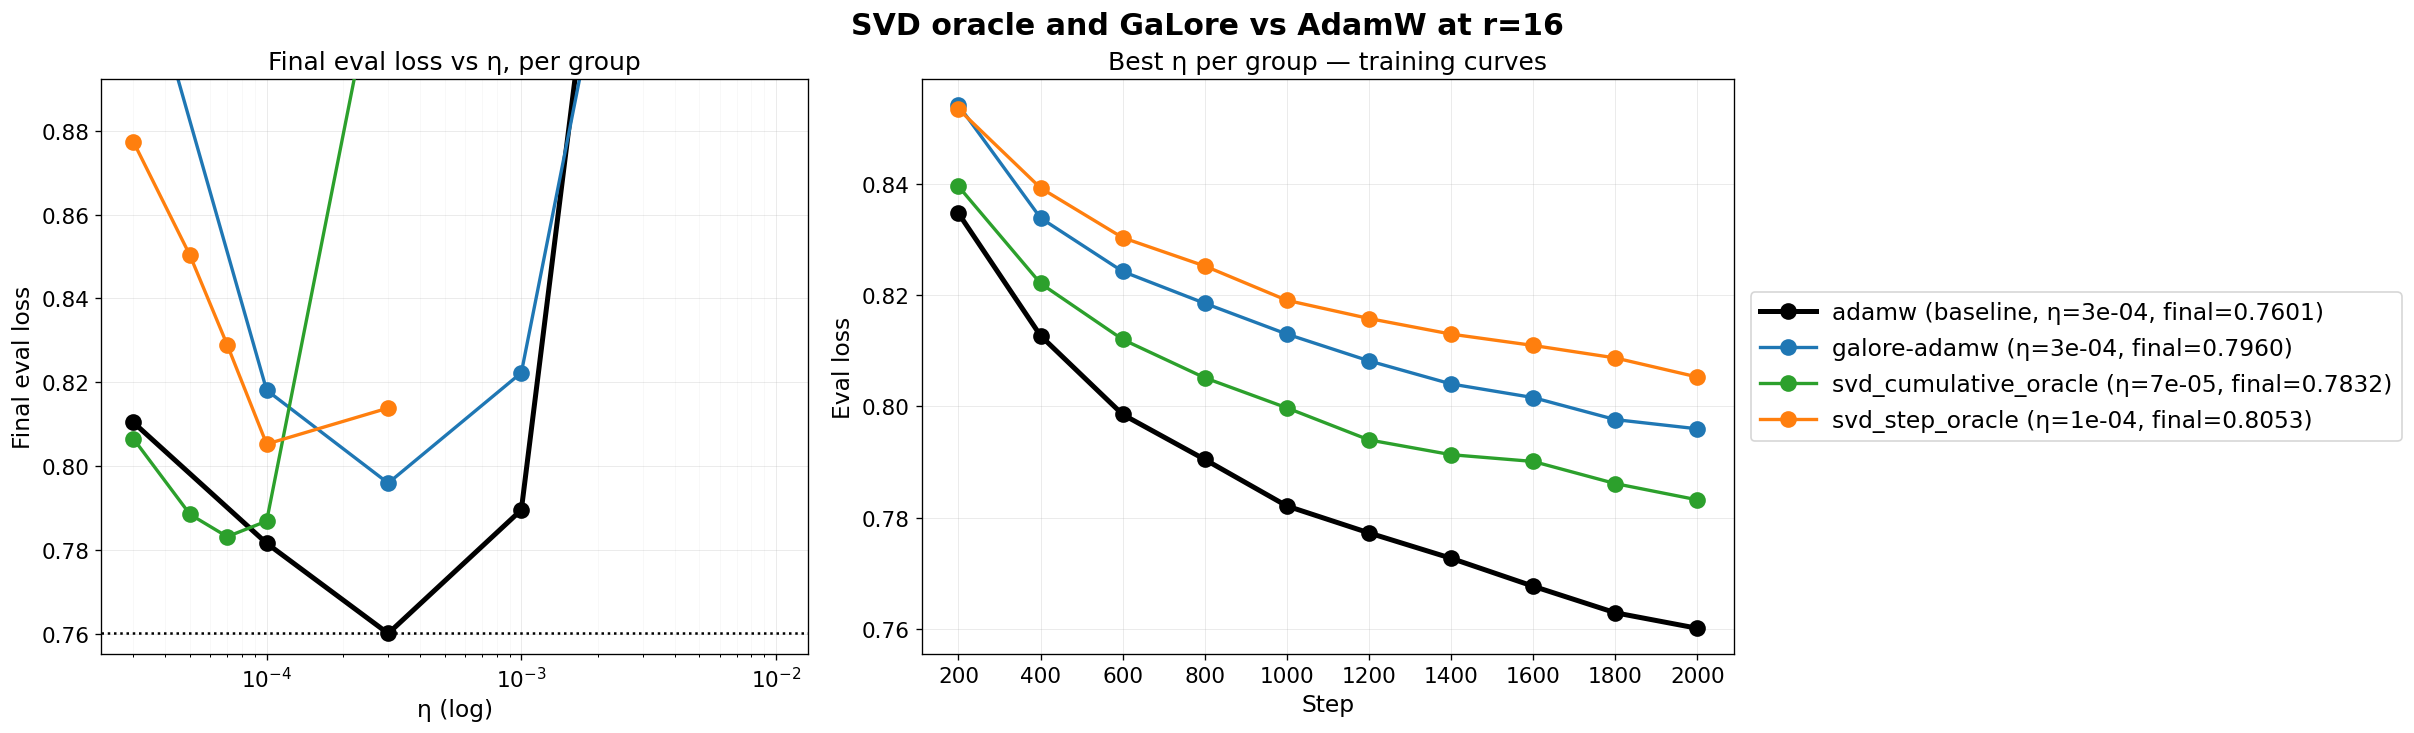

In [15]:
standard_sweep_figure(
    svd_runs,
    group_key_fn=lambda c: c["training_mode"],
    color_map=MODE_COLORS,
    reference_runs=all_runs,
    extra_baselines=(("galore-adamw", "#1f77b4"),),
    suptitle="SVD oracle and GaLore vs AdamW",
)
plt.show()

## LoRA+ (η, m) co-sweep — AdamW, r=16, 1 epoch

In [16]:
# AdamW LoRA+ runs. Drop m=1 (== plain adamw, redundant) and m≥32 (training
# blows up at this scale).
lp_runs = load_runs(
    where={"optimizer": "adamw",
           "lora_plus_multiplier": lambda m: 1.0 < float(m) < 32.0},
    key_axes=("lora_plus_multiplier", "lr"),
    logs_root="../logs",
)
print(f'Loaded {len(lp_runs)} AdamW LoRA+ runs (merged, m ∈ (1, 32))')
for cfg, evs in sorted(lp_runs, key=lambda x: (x[0].get('lora_plus_multiplier', 1), x[0]['lr'])):
    print(f"  m={cfg.get('lora_plus_multiplier', 1):.0f}  "
          f"η={cfg['lr']:.0e}  final={evs[-1]['eval_loss']:.4f}")

Loaded 8 AdamW LoRA+ runs (merged, m ∈ (1, 32))
  m=4  η=1e-05  final=0.8163
  m=4  η=3e-05  final=0.7905
  m=4  η=1e-04  final=0.7626
  m=4  η=3e-04  final=0.7644
  m=16  η=1e-05  final=0.7940
  m=16  η=3e-05  final=0.7684
  m=16  η=1e-04  final=0.7585
  m=16  η=3e-04  final=0.8128


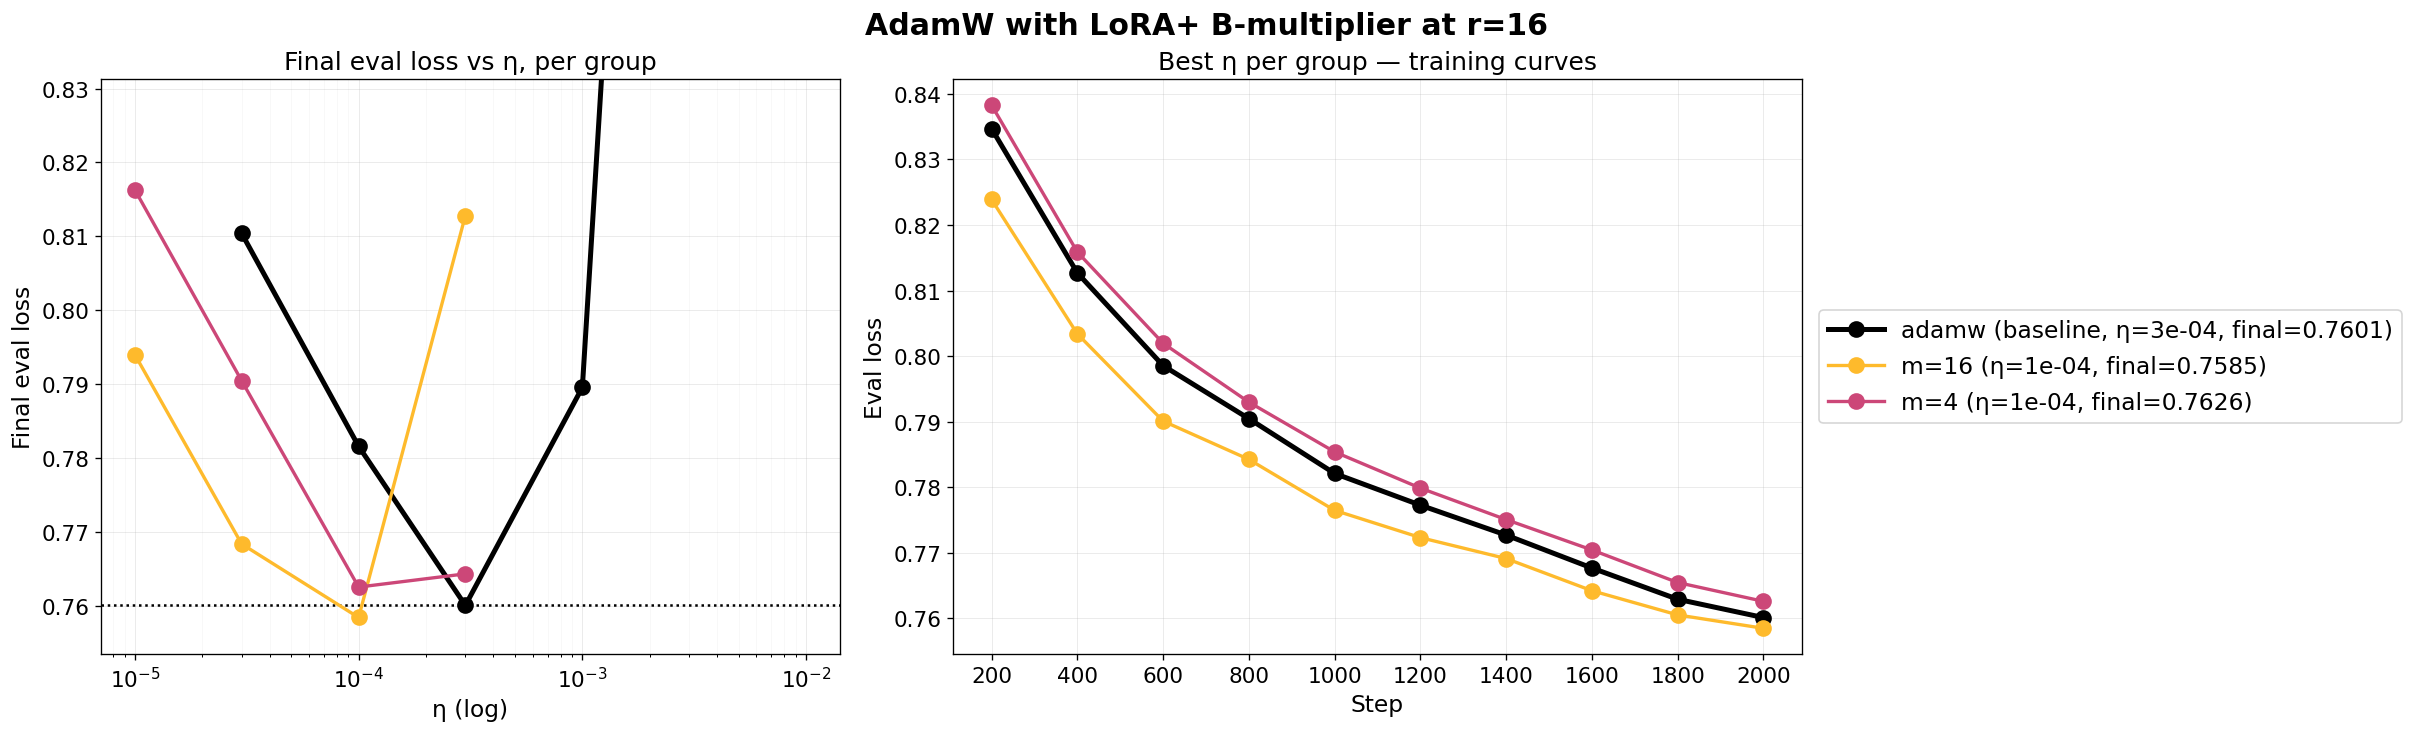

In [17]:
def _lp_group(cfg):
    return f"m={int(round(cfg.get('lora_plus_multiplier', 1.0)))}"

LP_COLOR_MAP = {f"m={m}": c for m, c in M_COLORS.items()}

standard_sweep_figure(
    lp_runs,
    group_key_fn=_lp_group,
    color_map=LP_COLOR_MAP,
    same_value_axes=(),  # explicit m axis in group label
    reference_runs=all_runs,
    suptitle="AdamW with LoRA+ B-multiplier",
)
plt.show()